# 18. Your Data, Your Schema

**The question.** Seventeen notebooks measured how to build and judge person-ER on *this
lab's* corpora. What does it actually take to point the whole apparatus at YOUR data and
YOUR schema — and which of the series' conclusions survive the move? This is the teaching
chapter: the reader leaves with the adaptation recipe, each step demonstrated live and
each step pointing back at the notebook that earned it.

**Two adaptations, both live at smoke.** ADP-01 ports the pipeline to the ONC
patient-matching corpus — a genuinely different schema (full DOB as an Excel-style serial,
an SSN-format field, street addresses, *no released answer key*) — and counts the
**lines of configuration changed** as the headline number, then runs the acceptance
sequence: audit-applicability check, serialization through the ported schema, the
invariance battery as acceptance test, an NB12-recipe retrain on conservative
pseudo-labels, and a small dedup eval on pseudo-truth (within-lab only). ADP-02 converts
dedup to two-source **linkage** on real NC data: county-68 snapshot A vs snapshot B as two
sources, same-NCID as linkage truth, candidate pairs cross-source only. The NC-vs-OH
cross-STATE arm (full-DOB vs no-DOB identifiability contrast) is `# [RUN-IN-TARGET node]`
— Ohio's acquisition is user-side per DATA_GOVERNANCE.md.

**Scope honesty, up front.** One seed, one ONC segment, one county, one snapshot pair:
every verdict below is a demonstration, read against BOTH MET-04 detectability bars. ONC
has no answer key, so its labels are FS-agreement pseudo-labels and every ONC number is
**pseudo-truth, within-lab only** — the NB11 circularity caveat applies in full. Real NC
person fields are masked in every display per DATA_GOVERNANCE.md; only aggregates are
registered. The ranking convention from the Wave-4 review is in force throughout: **AUC
scores the raw cosine** (rules enter rank-natively); entity operating points keep
calibrated probabilities; every registered ranking artifact declares its scored
representation in meta.

In [1]:
import subprocess
import time

import jellyfish
import numpy as np
import pandas as pd
import requests
import yaml
from IPython.display import display
from scipy.stats import rankdata

from er_lab.blocking import ann, matchkeys, sparse
from er_lab.cluster.schemes import transitive_closure
from er_lab.config import REPO_ROOT, config_hash, load_config_from_env, set_all_seeds
from er_lab.data import loaders
from er_lab.data.loaders import load_ohio, load_onc
from er_lab.data.schema import NON_TEXT_ROLES, ROLES
from er_lab.eval.bootstrap import bootstrap_ci, paired_delta
from er_lab.eval.operating_points import find_threshold_for_precision
from er_lab.infra.artifacts import ArtifactRegistry
from er_lab.infra.device import describe_platform
from er_lab.models.encoders import build_encoder
from er_lab.noise.channels import fetch_lexicon, load_lexicon, raw_unparse
from er_lab.probes.battery import battery_report, build_probe_set
from er_lab.reporting import figures
from er_lab.reporting.cards import conjecture_card, verdict_box
from er_lab.score.calibrate import fit_calibrator
from er_lab.serialize import serialize_frame, serialize_record
from er_lab.train.loop import train_encoder

cfg = load_config_from_env()
registry = ArtifactRegistry.from_env()
figures.setup_style()
set_all_seeds(cfg.run.seed)
NB_T0 = time.time()
SECTION_TIMES: list[tuple[str, float]] = []


def tick(label: str, t0: float) -> None:
    """Record and print one section's wall-clock — the smoke budget is measured, not vibes."""
    secs = time.time() - t0
    SECTION_TIMES.append((label, secs))
    print(f"[section timing] {label}: {secs:.0f}s")

In [2]:
# Tier banner — where and under what config this run happened.
print(f"tier        = {cfg.run.tier}")
print(f"config hash = {config_hash(cfg)}")
for key, val in describe_platform().items():
    print(f"  {key:>14}: {val}")

tier        = smoke
config hash = 129c9d9243ca
              os: Linux-6.18.44-fc-v22-x86_64-with-glibc2.39
          python: 3.11.15
           torch: 2.13.0+cu130
  cuda_available: False
   mps_available: False
       cpu_count: 4
          ram_gb: 15.7


## Tier constants

Encoder shape and step budget are the tier table notebooks 09/12/13/14 share, so the NB12
training recipe transfers verbatim (scratch-char is the smoke regime — HF weights are
unreachable from this container, notes/COMPAT.md). Protocol constants (precision targets,
the pseudo-label conservatism dial, the override's birth-year tolerance) are identical at
every tier and pre-registered in the cards; substrate sizes and analysis budgets scale
with tier, every subsample stated where it happens. Smoke budget for the whole notebook:
**<= ~30 min uncontended on the 4-CPU container** (concurrent builds can inflate
wall-clock 2-4x; per-section timings print at the end).

In [3]:
TIER = str(cfg.run.tier)
SIZES = {  # tier-scaled substrate sizes (None = the full substrate)
    "smoke": {"onc_rows": 20_000, "nc_ncids": 5_000},
    "mid": {"onc_rows": 92_440, "nc_ncids": 40_000},
    "target": {"onc_rows": None, "nc_ncids": None},
    "analytical": {"onc_rows": 20_000, "nc_ncids": 5_000},
}[TIER]
ONC_SEGMENTS = {"smoke": ["S"], "mid": ["S"], "target": None, "analytical": ["S"]}[TIER]
STEPS_BY_TIER = {"smoke": 250, "mid": 2000, "target": 4000, "analytical": 250}
MODEL_SHAPE = {
    "smoke": {"dim": 128, "layers": 2, "heads": 4, "max_len": 128},
    "mid": {"dim": 256, "layers": 4, "heads": 4, "max_len": 192},
    "target": {"dim": 384, "layers": 6, "heads": 6, "max_len": 192},
    "analytical": {"dim": 128, "layers": 2, "heads": 4, "max_len": 128},
}[TIER]
STEPS = STEPS_BY_TIER[TIER]
ENC_BATCH = 256  # inference encode batch
GRID = {"smoke": 60, "mid": 150, "target": 200, "analytical": 60}[TIER]
N_BOOT = {"smoke": 400, "mid": 1000, "target": 2000, "analytical": 400}[TIER]
N_BOOT_AUC = {"smoke": 300, "mid": 600, "target": 1000, "analytical": 300}[TIER]
AUC_CAP = {"smoke": 60_000, "mid": 200_000, "target": 500_000, "analytical": 60_000}[TIER]
PROBE_N = {"smoke": 120, "mid": 200, "target": 200, "analytical": 120}[TIER]
K_TRANSFER = 10  # the BAS-02 transfer row's matched budget (bas02's noise-slice k)
# protocol constants (identical at every tier; pre-registered in the cards below):
PREC_TARGETS = (0.99, 0.995)  # fixed B-cubed entity-precision operating points (PLAN §5)
PREC_PRIMARY = 0.99
PSEUDO_THR = 0.95  # conservative FS-agreement pseudo-label threshold (card ADP-01)
PSEUDO_MIN_FIELDS = 4  # a pair with fewer jointly-present fields cannot pseudo-link
BY_TOL = 1  # birth-year tolerance for the NC override key (NB14's dob-absent fallback)
NC_OVERLAP = 0.7  # share of sampled NCIDs present in BOTH linkage sources
CONFIG_LINES_BAR = 30  # card ADP-01 P1: max lines of config changed
BATTERY_TOL_COS = 0.15  # card ADP-01 P2: should-hold mean-cos tolerance vs baseline
BATTERY_TOL_AUC = 0.10  # card ADP-01 P2: must-not-hold AUC tolerance vs baseline
PRIMARY_SEED = int(cfg.run.seed)
DATA_ROOT = REPO_ROOT / str(cfg.paths.data_root)

cfg.model.kind = "scratch_char"
cfg.model.dim = MODEL_SHAPE["dim"]
cfg.model.layers = MODEL_SHAPE["layers"]
cfg.model.heads = MODEL_SHAPE["heads"]
cfg.model.max_len = MODEL_SHAPE["max_len"]
cfg.train.steps = STEPS
BATCH = int(cfg.train.batch_size)
SER_SCHEME, SER_MISSING = str(cfg.serialize.scheme), str(cfg.serialize.missing)
print(f"tier={TIER}: ONC segments {ONC_SEGMENTS} @ {SIZES['onc_rows']} rows, "
      f"NC {SIZES['nc_ncids']} NCIDs (overlap {NC_OVERLAP}); encoder {MODEL_SHAPE}, "
      f"steps={STEPS} x batch {BATCH}; grid {GRID}, n_boot {N_BOOT}/{N_BOOT_AUC} (auc), "
      f"auc cap {AUC_CAP:,}, probes {PROBE_N}/slice")
print(f"protocol: precision {PREC_TARGETS} (primary {PREC_PRIMARY}); pseudo-label threshold "
      f"{PSEUDO_THR} over >= {PSEUDO_MIN_FIELDS} joint fields; birth-year tol ±{BY_TOL}; "
      f"serialization {SER_SCHEME}/{SER_MISSING} (the TRN-05 winning arm, inherited)")

tier=smoke: ONC segments ['S'] @ 20000 rows, NC 5000 NCIDs (overlap 0.7); encoder {'dim': 128, 'layers': 2, 'heads': 4, 'max_len': 128}, steps=250 x batch 64; grid 60, n_boot 400/300 (auc), auc cap 60,000, probes 120/slice
protocol: precision (0.99, 0.995) (primary 0.99); pseudo-label threshold 0.95 over >= 4 joint fields; birth-year tol ±1; serialization colval/token (the TRN-05 winning arm, inherited)


## 1. Upstreams: what the port inherits through the registry

The DAG-declared inputs (`declared_schemas`, `calibrated_corpus`) plus the reference
instruments this chapter compares against: `invariance_battery` (the calibrated-corpus
acceptance baseline), `met04_power_table` (both detectability bars), `met07_splits` (the
split discipline the new corpora must reproduce), and `corpus_registry` (the NC
aligned-pair path ADP-02 reads).

`TEXT_ROLES` discipline inherits notebook 08's **measured decision**: `full_name` is
EXCLUDED — it roughly doubles serialized length (forcing truncation at the smoke byte
window) and NB05 leaves it stale under nickname/typo edits, so keeping it would leak the
clean name past the injected noise. Neither ONC nor the NC snapshots declare a `full_name`
role, so the lock is inherited trivially — but it is the rule a new schema must obey, so
it is stated here where the porting happens.

In [4]:
t_sec = time.time()
schemas, schemas_meta = registry.load("declared_schemas", tier=cfg.run.tier)
corpus, corpus_meta = registry.load("calibrated_corpus", tier=cfg.run.tier)
splits, splits_meta = registry.load("met07_splits", tier=cfg.run.tier)
battery_base, battery_meta = registry.load("invariance_battery", tier=cfg.run.tier)
met04, met04_meta = registry.load("met04_power_table", tier=cfg.run.tier)
creg, creg_meta = registry.load("corpus_registry", tier=cfg.run.tier)

CORPUS_PROVENANCE = (
    f"calibrated_corpus run {corpus_meta['created_at']} (cfg {corpus_meta['config_hash']}, "
    f"tier {corpus_meta['tier']}, seed {corpus_meta['extra']['seed']})"
)
print(f"reference corpus: {CORPUS_PROVENANCE}")
print(f"  {len(corpus):,} records / {corpus['entity_id'].nunique():,} entities "
      "(public historical records; the ADP-01 lines-of-config comparison is against this "
      "path's own schema yaml)")
print(f"declared_schemas carries {len(schemas)} schemas: {sorted(schemas)}")
_straddle = splits["metadata"]["checks"]["entity_disjoint"]["entities_straddling"]
assert _straddle == 0, "inherited split discipline must show zero straddling entities"
print(f"split discipline inherited (met07_splits): entity-disjoint halves, "
      f"{_straddle} straddling entities — the construction ONC/NC splits below reproduce")

# BOTH MET-04 bars, quoted from the registered meta (the single-seed reading rule).
SD_REPLICATE = float(met04_meta["extra"]["sd_replicate"])
BAR_SINGLE = float(met04_meta["extra"]["detect_bar_single_seed"])
BAR_FULL = float(met04_meta["extra"]["detect_bar_residual_inclusive"])
print(f"MET-04 bars (B3F1 units, from met04_power_table meta): "
      f"detect_bar_single_seed={BAR_SINGLE:.4f}, "
      f"detect_bar_residual_inclusive={BAR_FULL:.4f} (sd_replicate={SD_REPLICATE:.4f}) — "
      "every single-seed margin below is read against both; smaller margins are "
      "run-to-run noise, not findings.")
_batt_trained = battery_base[battery_base["encoder"] == "trn05:colval/token"]
assert len(_batt_trained), "invariance_battery has no trained-arm rows to baseline against"
print(f"battery baseline: {len(_batt_trained)} trained-arm slices "
      f"(winner arm {battery_meta['extra']['winner_arm']}, "
      f"steps {battery_meta['extra']['steps']}) — the acceptance reference for step (c)")
assert battery_meta["extra"]["winner_arm"] == f"{SER_SCHEME}/{SER_MISSING}", (
    "serialization drifted from the TRN-05 winning arm the battery baseline used"
)
tick("§1 upstreams + bars", t_sec)

reference corpus: calibrated_corpus run 2026-08-26T02:41:13.372218+00:00 (cfg 129c9d9243ca, tier smoke, seed 17)
  32,259 records / 2,507 entities (public historical records; the ADP-01 lines-of-config comparison is against this path's own schema yaml)
declared_schemas carries 6 schemas: ['bpid', 'fake_1000', 'historical_50k', 'nc_voter', 'ohio', 'onc']
split discipline inherited (met07_splits): entity-disjoint halves, 0 straddling entities — the construction ONC/NC splits below reproduce
MET-04 bars (B3F1 units, from met04_power_table meta): detect_bar_single_seed=0.0862, detect_bar_residual_inclusive=0.0865 (sd_replicate=0.0305) — every single-seed margin below is read against both; smaller margins are run-to-run noise, not findings.
battery baseline: 10 trained-arm slices (winner arm colval/token, steps 250) — the acceptance reference for step (c)
[section timing] §1 upstreams + bars: 0s


## 2. Two conjectures, registered before anything is ported

Cards first (PLAN §5/§6): both register now — before the ONC schema is written, before a
single record loads, before any pseudo-label exists. Decision rules live inside the
predictions; the verdict boxes at the end score exactly them and nothing else.

In [5]:
_ = conjecture_card(
    card_id="ADP-01",
    conjecture=(
        "Pointing this lab at a new corpus and schema (ONC patient matching: full DOB as "
        "an Excel-style serial, an SSN-format field, street addresses, no released answer "
        "key) is a configuration exercise, not an engineering project: one DeclaredSchema "
        "YAML plus dotlist overrides port the whole pipeline with zero er_lab package "
        "edits, the serialization and raw-cosine scoring conventions transfer unchanged, "
        "and the invariance battery serves as the acceptance test against the "
        "calibrated-corpus baseline."
    ),
    pressure=(
        "the adaptation recipe, executed end to end on the ONC corpus at tier scale: "
        "(a) audit-applicability check (NB04 contract: stable person key + >= 2 temporal "
        "versions), (b) serialization through the ported schema under NB08's TEXT_ROLES "
        "discipline, (c) the probes.battery invariance suite as acceptance test, "
        "(d) NB12-recipe scratch-char retraining on conservative FS-agreement "
        "pseudo-labels (threshold 0.95 on a mean Jaro-Winkler/exact agreement score over "
        ">= 4 jointly-present fields, transitive closure; NB11's circularity caveat "
        "carried), (e) a small dedup eval on pseudo-truth, within-lab only"
    ),
    property=(
        "lines-of-config-changed (non-comment schema YAML lines + dotlist override lines "
        "+ package files edited, git-verified) and the per-slice battery statistics (mean "
        "cosine for should-hold slices, separation AUC vs pseudo-true pairs for "
        "must-not-hold slices) side by side with the calibrated-corpus battery baseline"
    ),
    metric=(
        "the adaptation report: step x outcome rows, the lines-of-config headline, the "
        "battery pass table, and a pseudo-truth dedup operating point (B-cubed F1 at "
        "entity precision 0.99 with entity-BCa CIs) — plus the transfer table "
        "re-measuring three series conclusions (PRS-01 parsing difference-in-differences "
        "sign, BAS-02 bm25-vs-dense pair-completeness sign at k=10, HYB-01 override "
        "marginal sign) on the ONC slice with CIs; registered as adp01_adaptation_report"
    ),
    prediction=(
        "P1: total configuration changed <= 30 lines (schema YAML non-comment lines + "
        "dotlist overrides), with ZERO package edits (git-verified). P2 (acceptance "
        "battery): on every probe slice populated in BOTH batteries, the ONC encoder's "
        "should-hold mean cosine is no more than 0.15 below the calibrated-corpus trained "
        "baseline, and each must-not-hold separation AUC is no more than 0.10 below it "
        "(empty slices are reported, not scored — e.g. Excel-serial DOBs defeat the "
        "birth-year probe by construction). P3 (applicability honesty): the NB04 noise "
        "audit is declared NOT APPLICABLE (single release, no stable person key) and the "
        "generic-noise fallback carries its stated caveat. Decision rule, pre-registered: "
        "REFUTED iff P1 fails; CONFIRMED iff P1 AND P2 AND P3; UNEXPLAINED otherwise (a "
        "battery miss means the port is not yet acceptance-ready at this budget — that "
        "reading is the point of the test). Pseudo-truth is FS-agreement-born, so every "
        "FS-flattering comparison is biased in FS's favor and is read as within-lab only; "
        "one seed, one segment: a demonstration against the MET-04 bars, never an "
        "adjudication."
    ),
    registry=registry,
)

### Conjecture card `ADP-01`

| | |
|---|---|
| **Conjecture** | Pointing this lab at a new corpus and schema (ONC patient matching: full DOB as an Excel-style serial, an SSN-format field, street addresses, no released answer key) is a configuration exercise, not an engineering project: one DeclaredSchema YAML plus dotlist overrides port the whole pipeline with zero er_lab package edits, the serialization and raw-cosine scoring conventions transfer unchanged, and the invariance battery serves as the acceptance test against the calibrated-corpus baseline. |
| **Pressure (dial)** | the adaptation recipe, executed end to end on the ONC corpus at tier scale: (a) audit-applicability check (NB04 contract: stable person key + >= 2 temporal versions), (b) serialization through the ported schema under NB08's TEXT_ROLES discipline, (c) the probes.battery invariance suite as acceptance test, (d) NB12-recipe scratch-char retraining on conservative FS-agreement pseudo-labels (threshold 0.95 on a mean Jaro-Winkler/exact agreement score over >= 4 jointly-present fields, transitive closure; NB11's circularity caveat carried), (e) a small dedup eval on pseudo-truth, within-lab only |
| **Embedding property** | lines-of-config-changed (non-comment schema YAML lines + dotlist override lines + package files edited, git-verified) and the per-slice battery statistics (mean cosine for should-hold slices, separation AUC vs pseudo-true pairs for must-not-hold slices) side by side with the calibrated-corpus battery baseline |
| **System metric** | the adaptation report: step x outcome rows, the lines-of-config headline, the battery pass table, and a pseudo-truth dedup operating point (B-cubed F1 at entity precision 0.99 with entity-BCa CIs) — plus the transfer table re-measuring three series conclusions (PRS-01 parsing difference-in-differences sign, BAS-02 bm25-vs-dense pair-completeness sign at k=10, HYB-01 override marginal sign) on the ONC slice with CIs; registered as adp01_adaptation_report |
| **Pre-registered prediction** | P1: total configuration changed <= 30 lines (schema YAML non-comment lines + dotlist overrides), with ZERO package edits (git-verified). P2 (acceptance battery): on every probe slice populated in BOTH batteries, the ONC encoder's should-hold mean cosine is no more than 0.15 below the calibrated-corpus trained baseline, and each must-not-hold separation AUC is no more than 0.10 below it (empty slices are reported, not scored — e.g. Excel-serial DOBs defeat the birth-year probe by construction). P3 (applicability honesty): the NB04 noise audit is declared NOT APPLICABLE (single release, no stable person key) and the generic-noise fallback carries its stated caveat. Decision rule, pre-registered: REFUTED iff P1 fails; CONFIRMED iff P1 AND P2 AND P3; UNEXPLAINED otherwise (a battery miss means the port is not yet acceptance-ready at this budget — that reading is the point of the test). Pseudo-truth is FS-agreement-born, so every FS-flattering comparison is biased in FS's favor and is read as within-lab only; one seed, one segment: a demonstration against the MET-04 bars, never an adjudication. |

*Immutable — sha256 `5f6c222b18e4`; registered before the affected runs, never edited (PLAN §5).*


In [6]:
_ = conjecture_card(
    card_id="ADP-02",
    conjecture=(
        "The dedup pipeline converts to two-source linkage by configuration and "
        "pair-universe restriction alone — candidate generation, scoring, calibration, "
        "clustering and metrics run unchanged on real NC data with snapshot A and "
        "snapshot B as the two sources and same-NCID as linkage truth — and HYB-01's "
        "finding that the exact-key override earns its place transfers to the linkage "
        "setting."
    ),
    pressure=(
        "linkage mode on the county-68 aligned substrate: two sources (2024 vs 2026 "
        "snapshots) with ~70% true overlap, NCID-disjoint train/eval halves, an "
        "NB12-recipe scratch-char encoder retrained on the train half's cross-snapshot "
        "positives (NCID labels; NB01 measured dup-NCID 3.2-3.7%, the truth-error "
        "caveat), candidate pairs restricted cross-source, systems {JW-FS stand-in, "
        "embedding, embedding + exact-name+birth-year override (dob absent: birth key = "
        "snapshot_year - age, +/-1)}"
    ),
    property=(
        "cross-source pair ranking (ROC AUC on the declared representation: raw cosine "
        "for the embedding, the override applied rank-natively) and the conversion cost "
        "(package edits, within-source candidates dropped by the linkage filter)"
    ),
    metric=(
        "entity-level linkage B-cubed F1 at fixed precision {0.99, 0.995} with "
        "entity-unit BCa 95% CIs and paired deltas on shared resamples, over the "
        "eval-half record universe (linked pairs + unlinked singletons); registered as "
        "adp02_linkage_results"
    ),
    prediction=(
        "P1 (conversion): zero er_lab package edits (git-verified); the linkage "
        "restriction is a stated in-notebook pair filter. P2 (HYB-01 transfer): the "
        "paired B-cubed F1 delta of embedding+override minus embedding at precision 0.99 "
        "is >= 0 and not sign-stably negative. P3: the override does not hurt the pair "
        "ranking either — hybrid AUC >= embedding AUC (point estimate, raw-cosine "
        "scale). Decision rule, pre-registered: REFUTED iff P1 fails or the override "
        "delta is sign-stably negative; CONFIRMED iff P1 AND P2 AND P3; UNEXPLAINED "
        "otherwise. Single seed, one county, one snapshot pair: a demonstration read "
        "against BOTH MET-04 bars (detect_bar_single_seed and "
        "detect_bar_residual_inclusive, quoted from met04_power_table meta); the NC-vs-OH "
        "cross-state arm is RUN-IN-TARGET(node) and user-side data-gated."
    ),
    registry=registry,
)

### Conjecture card `ADP-02`

| | |
|---|---|
| **Conjecture** | The dedup pipeline converts to two-source linkage by configuration and pair-universe restriction alone — candidate generation, scoring, calibration, clustering and metrics run unchanged on real NC data with snapshot A and snapshot B as the two sources and same-NCID as linkage truth — and HYB-01's finding that the exact-key override earns its place transfers to the linkage setting. |
| **Pressure (dial)** | linkage mode on the county-68 aligned substrate: two sources (2024 vs 2026 snapshots) with ~70% true overlap, NCID-disjoint train/eval halves, an NB12-recipe scratch-char encoder retrained on the train half's cross-snapshot positives (NCID labels; NB01 measured dup-NCID 3.2-3.7%, the truth-error caveat), candidate pairs restricted cross-source, systems {JW-FS stand-in, embedding, embedding + exact-name+birth-year override (dob absent: birth key = snapshot_year - age, +/-1)} |
| **Embedding property** | cross-source pair ranking (ROC AUC on the declared representation: raw cosine for the embedding, the override applied rank-natively) and the conversion cost (package edits, within-source candidates dropped by the linkage filter) |
| **System metric** | entity-level linkage B-cubed F1 at fixed precision {0.99, 0.995} with entity-unit BCa 95% CIs and paired deltas on shared resamples, over the eval-half record universe (linked pairs + unlinked singletons); registered as adp02_linkage_results |
| **Pre-registered prediction** | P1 (conversion): zero er_lab package edits (git-verified); the linkage restriction is a stated in-notebook pair filter. P2 (HYB-01 transfer): the paired B-cubed F1 delta of embedding+override minus embedding at precision 0.99 is >= 0 and not sign-stably negative. P3: the override does not hurt the pair ranking either — hybrid AUC >= embedding AUC (point estimate, raw-cosine scale). Decision rule, pre-registered: REFUTED iff P1 fails or the override delta is sign-stably negative; CONFIRMED iff P1 AND P2 AND P3; UNEXPLAINED otherwise. Single seed, one county, one snapshot pair: a demonstration read against BOTH MET-04 bars (detect_bar_single_seed and detect_bar_residual_inclusive, quoted from met04_power_table meta); the NC-vs-OH cross-state arm is RUN-IN-TARGET(node) and user-side data-gated. |

*Immutable — sha256 `bab558be79e0`; registered before the affected runs, never edited (PLAN §5).*


## 3. ADP-01 — porting the lab to ONC, step by step

### 3a. The schema is the port: one YAML, counted line by line

The DeclaredSchema below is written *here, in the notebook* — it is the entire
data-mapping work of the port. It maps ONC's verbatim CSV header onto the lab's fixed
role vocabulary; `EnterpriseID` is declared as the truth key **and §3b then measures
what that declaration is worth** (spoiler: the challenge answer key was never released).
The cell asserts the in-notebook YAML matches the schema the lab ships
(`configs/schemas/onc.yaml`, registered in `declared_schemas` by notebook 01), then
counts the headline number: **lines of configuration changed vs the calibrated-corpus
path** — schema lines + dotlist overrides + package files edited (git-verified).

In [7]:
t_sec = time.time()
ONC_SCHEMA_YAML = """\
name: onc
record_id: __row__
entity_id: EnterpriseID
roles:
  given_name: FIRST
  middle_name: MIDDLE
  family_name: LAST
  name_suffix: SUFFIX
  dob: DOB
  sex: GENDER
  ssn_like: SSN
  street_address: [ADDRESS1, ADDRESS2]
  city: CITY
  state: STATE
  zip: ZIP
  phone: PHONE
  email: EMAIL
extra_keep: [PHONE2, MOTHERS_MAIDEN_NAME, MRN, ALIAS]
"""
mine = yaml.safe_load(ONC_SCHEMA_YAML)
shipped = yaml.safe_load((REPO_ROOT / "configs/schemas/onc.yaml").read_text())
assert mine == shipped, "in-notebook ONC schema diverges from the shipped configs/schemas/onc.yaml"
assert mine["roles"] == schemas["onc"]["roles"], (
    "in-notebook ONC roles diverge from the registered declared_schemas payload"
)
SCHEMA_LINES = len(
    [ln for ln in ONC_SCHEMA_YAML.splitlines() if ln.strip() and not ln.strip().startswith("#")]
)
DOTLIST_OVERRIDES = ["data.dataset=onc", "data.schema=configs/schemas/onc.yaml"]
_git = subprocess.run(
    ["git", "status", "--porcelain", "--", "src/er_lab"],
    cwd=REPO_ROOT, capture_output=True, text=True, timeout=30, check=False,
)
PACKAGE_EDITS = (
    len([ln for ln in _git.stdout.splitlines() if ln.strip()]) if _git.returncode == 0 else -1
)
LINES_TOTAL = SCHEMA_LINES + len(DOTLIST_OVERRIDES)
_ref_yaml = (REPO_ROOT / "configs/schemas/historical_50k.yaml").read_text()
_ref_lines = len(
    [ln for ln in _ref_yaml.splitlines() if ln.strip() and not ln.strip().startswith("#")]
)
print(f"THE HEADLINE: {LINES_TOTAL} lines of configuration changed, {PACKAGE_EDITS} package "
      "edits")
print(f"  schema yaml: {SCHEMA_LINES} non-comment lines (the calibrated-corpus path's own "
      f"historical_50k.yaml is {_ref_lines} — the port costs the same order of config)")
print(f"  dotlist overrides: {len(DOTLIST_OVERRIDES)} -> {DOTLIST_OVERRIDES}")
print(f"  package edits under src/er_lab (git status --porcelain): {PACKAGE_EDITS} "
      + ("(clean tree — zero edits, measured not asserted)" if PACKAGE_EDITS == 0
         else "<-- NOT ZERO: the P1 claim fails" if PACKAGE_EDITS > 0
         else "(git unavailable — could not verify)"))
print(f"  card ADP-01 P1 bar: <= {CONFIG_LINES_BAR} lines AND zero package edits")
tick("§3a schema + lines-of-config", t_sec)

THE HEADLINE: 20 lines of configuration changed, 0 package edits
  schema yaml: 18 non-comment lines (the calibrated-corpus path's own historical_50k.yaml is 12 — the port costs the same order of config)
  dotlist overrides: 2 -> ['data.dataset=onc', 'data.schema=configs/schemas/onc.yaml']
  package edits under src/er_lab (git status --porcelain): 0 (clean tree — zero edits, measured not asserted)
  card ADP-01 P1 bar: <= 30 lines AND zero package edits
[section timing] §3a schema + lines-of-config: 0s


### 3b. Loading ONC — and measuring what the "truth key" is worth

`data.loaders.load_onc` fetches segment CSVs from the challenge repo (research-use only,
never redistributed — DATA_GOVERNANCE.md). One wrinkle this container adds: the GitHub
*contents API* the loader uses for discovery is blocked here (proxy 400), while the raw
file host is reachable — so a small in-notebook fallback fetches the segment files
directly and retries, letting the loader's local-files path take over. That is a
**container workaround, not a package edit** (noted as a package gap: the loader could
fall back to canned segment names itself when `letters` is given).

At smoke ONE segment loads (`letters=['S']`, ~92k records) and a **contiguous band** of
20,000 rows is kept — contiguity matters because the files are sorted by last name, so
duplicate clusters sit near each other; a uniform row subsample would shatter them
(measured below). ONC displays are masked with the same cheap caution as NC displays:
the records are synthetic-ish, but governance treats them as research-use only.

In [8]:
t_sec = time.time()


def load_onc_with_fallback(letters):
    """load_onc, with a direct raw-host fetch when API discovery is blocked (see above)."""
    try:
        return load_onc(DATA_ROOT, letters=letters)
    except RuntimeError as exc:
        print(f"[workaround] ONC discovery failed ({str(exc)[:90]}...); fetching segment "
              "csvs from the raw host directly, then retrying via the loader's local path")
        segs = letters if letters is not None else list(loaders._ONC_SEGMENTS)
        for seg in segs:
            name = f"ONC Patient Matching Algorithm Challenge Test Dataset.{seg}.csv"
            url = loaders.ONC_RAW_BASE + "/" + requests.utils.quote(name)
            loaders._download(url, DATA_ROOT / "onc" / name)
        return load_onc(DATA_ROOT, letters=letters)


onc_full, onc_schema = load_onc_with_fallback(ONC_SEGMENTS)
N_BAND = SIZES["onc_rows"] or len(onc_full)
onc = onc_full.iloc[:N_BAND].reset_index(drop=True)


def _blank(s: pd.Series) -> pd.Series:
    """ONC missingness: NA or empty string (loaders deliver '' verbatim, never NaN)."""
    t = s.astype("string")
    return t.isna() | (t == "")


# the answer-key measurement: is the declared truth key worth anything within-corpus?
_uniq = int(onc_full["entity_id"].nunique())
KEY_IS_TRUTH = _uniq < len(onc_full)
print(f"loaded ONC segments {ONC_SEGMENTS}: {len(onc_full):,} records; band kept: "
      f"{len(onc):,} contiguous rows (files are last-name-sorted, so duplicate clusters "
      "are local; a uniform subsample would shatter them)")
_key = (onc_full["family_name"].astype("string").str.strip().str.casefold() + "|"
        + onc_full["given_name"].astype("string").str.strip().str.casefold() + "|"
        + onc_full["dob"].astype("string").str.strip())
_kvc = _key.value_counts()
_collided_full = int((_key.map(_kvc) >= 2).sum())
_keyb = _key.iloc[:N_BAND]
_collided_band = int((_keyb.map(_kvc.reindex(_keyb.unique())) >= 2).sum())
print(f"EnterpriseID: {_uniq:,} distinct values over {len(onc_full):,} rows -> "
      + ("carries dedup truth" if KEY_IS_TRUTH else
         "UNIQUE PER ROW: the declared truth key carries NO within-corpus dedup signal — "
         "the challenge answer key was never released (DATA_GOVERNANCE.md), so labels "
         "must be built in-lab (step d)"))
print(f"  yet duplicates plainly exist: {_collided_full:,} rows collide on exact "
      f"family|given|dob in the full segment ({_collided_band:,} in the band) — "
      "unlabeled duplication is the whole ADP-01 labeling problem")
_missing = pd.DataFrame({
    "role": ["given_name", "family_name", "dob", "ssn_like", "city", "zip", "sex",
             "middle_name", "email"],
}).assign(missing_share=lambda d: [float(_blank(onc[r]).mean()) for r in d["role"]])
print("missingness (NA or '' — the loaders' verbatim contract):")
display(_missing.round(4))
print(f"dob arrives as Excel-style serial integers (e.g. shape "
      f"'{'#' * len(str(onc['dob'].iloc[0]))}'), kept verbatim — the noise is the object "
      "of study; ssn_like is SSN-formatted, present on "
      f"{1 - float(_blank(onc['ssn_like']).mean()):.0%} of band rows — the full-DOB+SSN "
      "contrast with NC's no-DOB schema (MET-06's identifiability point, reversed)")


def mask_value(field: str, v: object) -> str:
    """Display masking (NB14's convention, extended to ONC's identifier-shaped fields)."""
    if pd.isna(v) or not str(v).strip():
        return "-"
    s = str(v).strip()
    if field in ("given_name", "family_name", "middle_name", "full_name"):
        return f"{s[0]}.({len(s)})"
    if field in ("ssn_like", "phone", "dob"):
        return "".join("#" if c.isdigit() else c for c in s)
    if field in ("street_address", "street", "email"):
        return f"{s[0]}…({len(s)})"
    return s  # city / state / zip / sex: coarse fields, NB03/NB04 convention


_show_roles = ["given_name", "family_name", "dob", "ssn_like", "city", "zip", "sex"]
_masked = pd.DataFrame(
    {f"row{i}": {r: mask_value(r, onc[r].iloc[i]) for r in _show_roles} for i in (0, 1, 2)}
)
print("\nmasked sample (initials+length for names, digit-shapes for identifiers):")
display(_masked)
tick("§3b ONC load + key measurement", t_sec)

[er_lab.data] onc: ONC patient-matching challenge (github.com/onc-healthit/patient-matching): no upstream LICENSE — research-use only, never redistributed, within-lab labels only; DOB is an Excel-style serial integer kept verbatim (DATA_GOVERNANCE.md).


loaded ONC segments ['S']: 92,440 records; band kept: 20,000 contiguous rows (files are last-name-sorted, so duplicate clusters are local; a uniform subsample would shatter them)
EnterpriseID: 92,440 distinct values over 92,440 rows -> UNIQUE PER ROW: the declared truth key carries NO within-corpus dedup signal — the challenge answer key was never released (DATA_GOVERNANCE.md), so labels must be built in-lab (step d)
  yet duplicates plainly exist: 6,815 rows collide on exact family|given|dob in the full segment (1,335 in the band) — unlabeled duplication is the whole ADP-01 labeling problem
missingness (NA or '' — the loaders' verbatim contract):


,role,missing_share
0,given_name,0.0352
1,family_name,0.0000
2,dob,0.0162
3,ssn_like,0.2438
4,city,0.0726
5,zip,0.0717
6,sex,0.0093
7,middle_name,0.6576
8,email,0.7633


dob arrives as Excel-style serial integers (e.g. shape '#####'), kept verbatim — the noise is the object of study; ssn_like is SSN-formatted, present on 76% of band rows — the full-DOB+SSN contrast with NC's no-DOB schema (MET-06's identifiability point, reversed)

masked sample (initials+length for names, digit-shapes for identifiers):


,row0,row1,row2
given_name,A.(3),R.(4),S.(5)
family_name,S.(2),S.(2),S.(2)
dob,#####,#####,#####
ssn_like,-,-,###-##-####
city,BRONX,BROOKLYN,-
zip,10456,11213,-
sex,MALE,FEMALE,FEMALE


[section timing] §3b ONC load + key measurement: 1s


### 3c. Step (a) — is the NB04 noise audit even applicable? (No — and that's the lesson)

Notebook 04's real-noise audit has a pre-registered **applicability contract**: it needs
a *stable person key* plus *>= 2 temporal versions* of the corpus, because its instrument
is the same-key cross-snapshot diff. The check below runs the contract on ONC and fails
it honestly on both clauses. The fallback is the **generic-noise path** (NB05's
generator with generic rather than audit-calibrated rates), and its caveat travels with
every downstream number: NSE-02 measured that generic generators mis-shape real error
channels, so nothing trained or evaluated under generic noise inherits NB05's
calibrated-fidelity evidence. A negative applicability finding, stated, beats a
fabricated audit — that is the audit-applicability contract doing its job.

In [9]:
t_sec = time.time()
N_VERSIONS = 1  # one published release of the challenge dataset; no temporal snapshots
STABLE_KEY = KEY_IS_TRUTH  # measured in §3b: EnterpriseID is unique per row
AUDIT_APPLICABLE = STABLE_KEY and N_VERSIONS >= 2
print(f"NB04 audit-applicability contract on ONC: stable person key = {STABLE_KEY} "
      f"(measured §3b), temporal versions = {N_VERSIONS} (>= 2 required) -> "
      f"applicable = {AUDIT_APPLICABLE}")
print("-> the NB04 same-key diff audit is NOT APPLICABLE to ONC. Fallback: the "
      "generic-noise path (NB05 generator, generic rates) wherever augmentation or "
      "synthetic stress is needed — WITH ITS CAVEAT: generic noise failed parts of "
      "NSE-02's fidelity acceptance, so ONC results under it carry no calibrated-noise "
      "evidence. This notebook therefore trains WITHOUT augmentation (the NB12 recipe's "
      "augment='none') and takes its noise from the data itself.")
STEP_ROWS: list[dict] = [
    {"row_type": "step", "step": "a. noise-audit applicability", "outcome": "NOT_APPLICABLE",
     "detail": "no stable key (EnterpriseID unique per row) + single release; generic-noise "
               "fallback with NSE-02 caveat stated", "n": float(N_VERSIONS)},
    {"row_type": "step", "step": "schema declaration (NB01)", "outcome": "DONE",
     "detail": f"{SCHEMA_LINES}-line YAML + {len(DOTLIST_OVERRIDES)} dotlist overrides, "
               f"{PACKAGE_EDITS} package edits", "n": float(LINES_TOTAL)},
]
tick("§3c audit applicability", t_sec)

NB04 audit-applicability contract on ONC: stable person key = False (measured §3b), temporal versions = 1 (>= 2 required) -> applicable = False
-> the NB04 same-key diff audit is NOT APPLICABLE to ONC. Fallback: the generic-noise path (NB05 generator, generic rates) wherever augmentation or synthetic stress is needed — WITH ITS CAVEAT: generic noise failed parts of NSE-02's fidelity acceptance, so ONC results under it carry no calibrated-noise evidence. This notebook therefore trains WITHOUT augmentation (the NB12 recipe's augment='none') and takes its noise from the data itself.
[section timing] §3c audit applicability: 0s


### 3d. Step (b) — serialization through the ported schema

The ported field set keeps NB08's six-role count and its discipline (fixed order, missing
as a visible `[MISSING]` token, `full_name` excluded) but follows ONC's schema: `dob` is
now a *real full-DOB field* and `ssn_like` replaces the calibrated corpus's `sex` as the
high-signal sixth role — the schema decides the field set, the discipline decides the
form. The smoke byte window is measured, not assumed: records past `max_len` truncate for
the encoder (stated, same as notebooks 08/12).

In [10]:
t_sec = time.time()
ONC_TEXT_ROLES = ["given_name", "family_name", "dob", "ssn_like", "city", "zip"]
ONC_KEEP = ["record_id", "entity_id"] + ONC_TEXT_ROLES
_loop_roles = [c for c in ONC_KEEP if c in ROLES and c not in NON_TEXT_ROLES]
assert _loop_roles == ONC_TEXT_ROLES, (
    f"training-loop role rule would diverge from ONC_TEXT_ROLES: {_loop_roles}"
)
onc_texts_all = serialize_frame(
    onc, text_roles=ONC_TEXT_ROLES, scheme=SER_SCHEME, missing=SER_MISSING
)
_blens = np.array([len(t.encode("utf-8")) for t in onc_texts_all])
print(f"ONC_TEXT_ROLES = {ONC_TEXT_ROLES} (full_name excluded per NB08's measured "
      "decision — inherited discipline; ONC declares no full_name role, so the lock "
      "costs nothing here)")
print(f"serialization {SER_SCHEME}/{SER_MISSING}: median {int(np.median(_blens))} bytes, "
      f"{float((_blens > MODEL_SHAPE['max_len'] - 1).mean()):.0%} of band records exceed "
      f"the smoke encoder's max_len={MODEL_SHAPE['max_len']} byte window (truncated for "
      "the dense arm — a real, stated smoke-window cost)")
_masked_row = {r: mask_value(r, onc[r].iloc[0]) for r in ONC_TEXT_ROLES}
print("masked serialization example (structure real, values masked):")
print("  " + serialize_record(_masked_row, text_roles=ONC_TEXT_ROLES, scheme=SER_SCHEME,
                              missing=SER_MISSING))
STEP_ROWS.append(
    {"row_type": "step", "step": "b. serialization via ported schema", "outcome": "DONE",
     "detail": f"{SER_SCHEME}/{SER_MISSING}, roles {ONC_TEXT_ROLES}; median "
               f"{int(np.median(_blens))} B, "
               f"{float((_blens > MODEL_SHAPE['max_len'] - 1).mean()):.0%} past the "
               f"{MODEL_SHAPE['max_len']}-byte smoke window",
     "n": float(np.median(_blens))}
)
tick("§3d serialization", t_sec)

ONC_TEXT_ROLES = ['given_name', 'family_name', 'dob', 'ssn_like', 'city', 'zip'] (full_name excluded per NB08's measured decision — inherited discipline; ONC declares no full_name role, so the lock costs nothing here)
serialization colval/token: median 163 bytes, 100% of band records exceed the smoke encoder's max_len=128 byte window (truncated for the dense arm — a real, stated smoke-window cost)
masked serialization example (structure real, values masked):
  [COL] given_name [VAL] A.(3) [COL] family_name [VAL] S.(2) [COL] dob [VAL] ##### [COL] ssn_like [VAL] - [COL] city [VAL] BRONX [COL] zip [VAL] 10456
[section timing] §3d serialization: 0s


### 3e. Labels without an answer key: the conservative FS-agreement pass

ONC ships no truth, so training labels are **pseudo-labels**: matchkey candidates scored
by the NB14-validated JW-FS stand-in (mean Jaro-Winkler over given/family/city + exact
agreement on dob/ssn/zip, averaged over fields present on both sides), linked only when
the score clears the conservative threshold **0.95 over >= 4 jointly-present fields**,
then closed transitively. Conservative means high-precision/low-recall *by construction
and by intent*: what the string-agreement teacher cannot see never enters pseudo-truth.

**The NB11 circularity caveat, carried verbatim in spirit:** training on a teacher's
predicted links instead of true labels costs real system quality, and the cost
concentrates exactly on the hard pairs the teacher itself gets wrong — the circularity
trap of administrative-key and legacy-linker supervision. Here the teacher is the
string-agreement pass itself, so every downstream "accuracy" number is *agreement with
an FS-shaped teacher*, biased in FS's favor and blind where the teacher is blind:
**pseudo-truth, within-lab only** — it can rank design variants inside this notebook,
never certify real-world accuracy.

In [11]:
t_sec = time.time()


def fs_agreement(recs_a: pd.DataFrame, recs_b: pd.DataFrame,
                 fuzzy: tuple = ("given_name", "family_name", "city"),
                 exact: tuple = ("dob", "ssn_like", "zip"),
                 min_fields: int = PSEUDO_MIN_FIELDS) -> tuple[np.ndarray, np.ndarray]:
    """NB14's jw_standin + a joint-presence guard: (score, n_joint_fields) per pair row.

    Mean JW over *fuzzy* + equality over *exact*, over fields non-blank on BOTH sides
    ('' counts as blank — the loaders' verbatim contract); pairs with fewer than
    *min_fields* jointly-present fields score 0 (too little evidence to pseudo-link).
    """
    n = len(recs_a)
    scores, counts = np.zeros(n), np.zeros(n)
    for fld in tuple(fuzzy) + tuple(exact):
        if fld not in recs_a.columns or fld not in recs_b.columns:
            continue
        va = recs_a[fld].astype("string").fillna("").to_numpy()
        vb = recs_b[fld].astype("string").fillna("").to_numpy()
        ok = (va != "") & (vb != "")  # NA and '' are both blank (the loaders' contract)
        sim = np.zeros(n)
        if fld in fuzzy:
            sim[ok] = [jellyfish.jaro_winkler_similarity(str(x), str(y))
                       for x, y in zip(va[ok], vb[ok])]
        else:
            sim[ok] = (va[ok] == vb[ok]).astype(float)
        scores += np.where(ok, sim, 0.0)
        counts += ok.astype(float)
    s = np.where(counts > 0, scores / np.maximum(counts, 1), 0.0)
    return np.where(counts >= min_fields, s, 0.0), counts


ONC_RECS = onc.set_index(onc["record_id"].astype(str))
onc_passes = matchkeys.default_passes(onc)
onc_cand = matchkeys.candidates(onc, passes=onc_passes)
_a = ONC_RECS.loc[onc_cand["a"].astype(str)].reset_index(drop=True)
_b = ONC_RECS.loc[onc_cand["b"].astype(str)].reset_index(drop=True)
_sc, _cnt = fs_agreement(_a, _b)
_linked = _sc >= PSEUDO_THR
links = onc_cand[_linked].reset_index(drop=True)
print(f"matchkey passes (module defaults on the ported schema): {onc_passes}")
print("  note: year(dob) on Excel serials keys the first 4 digits — a ~10-day serial "
      "bucket, not a calendar year; usable as a block key, said out loud")
print(f"candidates: {len(onc_cand):,} pairs on the {len(onc):,}-record band; "
      f"joint-field median {int(np.median(_cnt))}; conservative pass at "
      f"score >= {PSEUDO_THR} over >= {PSEUDO_MIN_FIELDS} joint fields -> "
      f"{len(links):,} pseudo-links")
_ssn_eq = ((_a["ssn_like"] == _b["ssn_like"])
           & ~(_blank(_a["ssn_like"]) | _blank(_b["ssn_like"])))
_dob_eq = ((_a["dob"] == _b["dob"]) & ~(_blank(_a["dob"]) | _blank(_b["dob"])))
print(f"  conservatism, characterized: {float(_ssn_eq[_linked].mean()):.0%} of links agree "
      f"on SSN (both present), {float(_dob_eq[_linked].mean()):.0%} on exact DOB serial — "
      "the teacher links only near-total agreement; heavily-corrupted true pairs are its "
      "structural blind spot (the circularity caveat above)")

sf_links = pd.DataFrame({"a": links["a"].astype(str), "b": links["b"].astype(str),
                         "prob": 1.0})
pseudo = transitive_closure(sf_links, threshold=0.5, records=pd.Index(ONC_RECS.index))
_pvc = pseudo.value_counts()
onc["pseudo_id"] = onc["record_id"].astype(str).map(pseudo).astype("string")
_multi_mass = int((pseudo.map(_pvc) >= 2).sum())
print(f"pseudo-entities: {int(pseudo.nunique()):,} over {len(onc):,} records; size "
      f"distribution {dict(_pvc.value_counts().sort_index())}; {_multi_mass:,} records sit "
      "in multi-record pseudo-entities (the training-pair supply)")

# pseudo-entity-disjoint halves — the met07 construction, reproduced on the new corpus
_rng_split = np.random.default_rng(PRIMARY_SEED + 11)
_ents = np.sort(pseudo.unique())
_tr_ent = set(_ents[_rng_split.random(len(_ents)) < 0.5])
onc_train = onc[onc["pseudo_id"].isin(_tr_ent)].reset_index(drop=True)
onc_eval = onc[~onc["pseudo_id"].isin(_tr_ent)].reset_index(drop=True)
_straddle_onc = len(set(onc_train["pseudo_id"]) & set(onc_eval["pseudo_id"]))
assert _straddle_onc == 0, "pseudo-entity-disjoint split must have zero straddlers"
print(f"pseudo-entity-disjoint split (met07 discipline reproduced): {len(onc_train):,} "
      f"train / {len(onc_eval):,} eval records, {_straddle_onc} straddling pseudo-entities "
      "(asserted). The teacher itself saw the whole band — deterministic string "
      "agreement, not a trained model; the ENCODER sees only the train half.")
STEP_ROWS.append(
    {"row_type": "step", "step": "d1. pseudo-labels (FS-agreement)", "outcome": "DONE",
     "detail": f"{len(links)} links at >= {PSEUDO_THR} over >= {PSEUDO_MIN_FIELDS} joint "
               f"fields; {_multi_mass} records in multi pseudo-entities; NB11 circularity "
               "caveat carried; within-lab only", "n": float(len(links))}
)
tick("§3e pseudo-labels + split", t_sec)

matchkey passes (module defaults on the ported schema): [['soundex(family_name)', 'year(dob)'], ['zip', 'initial(given_name)'], ['phone']]
  note: year(dob) on Excel serials keys the first 4 digits — a ~10-day serial bucket, not a calendar year; usable as a block key, said out loud
candidates: 118,222 pairs on the 20,000-record band; joint-field median 6; conservative pass at score >= 0.95 over >= 4 joint fields -> 381 pseudo-links
  conservatism, characterized: 44% of links agree on SSN (both present), 98% on exact DOB serial — the teacher links only near-total agreement; heavily-corrupted true pairs are its structural blind spot (the circularity caveat above)
pseudo-entities: 19,625 over 20,000 records; size distribution {1: 19256, 2: 363, 3: 6}; 744 records sit in multi-record pseudo-entities (the training-pair supply)
pseudo-entity-disjoint split (met07 discipline reproduced): 10,059 train / 9,941 eval records, 0 straddling pseudo-entities (asserted). The teacher itself saw the who

### 3f. Step (d) — the NB12-recipe retrain, budget stated

The established scratch recipe, unchanged: char/byte encoder (dim 128, 2 layers, 4 heads,
128-byte window at smoke), infonce / in-batch negatives / no augmentation, **exactly 250
optimizer steps at batch 64** (asserted from the history, never assumed). The only thing
that changed since notebook 12 is the data and the labels — which is the entire point of
the chapter. The tiny pseudo-positive pool is measured and stated: this is what
"training on your own unlabeled corpus, conservatively" buys at smoke scale.

In [12]:
t_sec = time.time()
set_all_seeds(PRIMARY_SEED)
onc_encoder = build_encoder(cfg)
N_PARAMS = int(sum(p.numel() for p in onc_encoder.parameters()))
_train_frame = onc_train[ONC_KEEP].copy()
_train_frame["entity_id"] = onc_train["pseudo_id"].astype("string")
_pool_ent = _train_frame["entity_id"].value_counts()
_n_pool_pairs = int((_pool_ent * (_pool_ent - 1) // 2).sum())
_t0 = time.time()
onc_encoder, onc_hist = train_encoder(
    onc_encoder, _train_frame, cfg, loss_name="infonce", miner_name="inbatch",
    augment_kind="none", steps=STEPS, seed=PRIMARY_SEED,
)
ONC_TRAIN_SECS = time.time() - _t0
assert len(onc_hist) == STEPS and int(onc_hist["step"].iloc[-1]) == STEPS, (
    f"budget violation: expected exactly {STEPS} optimizer steps"
)
print(f"trained on ONC pseudo-labels: infonce/inbatch/none, {STEPS} steps x batch {BATCH} "
      f"(asserted), {N_PARAMS:,} params -> {ONC_TRAIN_SECS:.0f}s; final loss "
      f"{float(onc_hist['loss'].tail(20).mean()):.4f}")
print(f"  positive-pair supply, stated: {_n_pool_pairs:,} distinct within-pseudo-entity "
      f"pairs from {int((_pool_ent >= 2).sum()):,} multi-record pseudo-entities — the "
      f"{STEPS * BATCH:,} pair draws resample this tiny pool heavily; a conservative "
      "teacher buys precision at the price of a starved positive supply (measured, "
      "the recipe's honest smoke-scale trade)")
_t0 = time.time()
EV_TEXTS = serialize_frame(onc_eval, text_roles=ONC_TEXT_ROLES, scheme=SER_SCHEME,
                           missing=SER_MISSING).tolist()
TR_TEXTS = serialize_frame(onc_train, text_roles=ONC_TEXT_ROLES, scheme=SER_SCHEME,
                           missing=SER_MISSING).tolist()
EV_EMB = onc_encoder.encode(EV_TEXTS, batch_size=ENC_BATCH)
TR_EMB = onc_encoder.encode(TR_TEXTS, batch_size=ENC_BATCH)
ONC_ENC_SECS = time.time() - _t0
ONC_ENC_RATE = (len(EV_TEXTS) + len(TR_TEXTS)) / ONC_ENC_SECS
print(f"encoded {len(EV_TEXTS) + len(TR_TEXTS):,} records in {ONC_ENC_SECS:.0f}s "
      f"({ONC_ENC_RATE:,.0f} rec/s on this container)")
STEP_ROWS.append(
    {"row_type": "step", "step": "d2. NB12-recipe retrain", "outcome": "DONE",
     "detail": f"scratch_char {MODEL_SHAPE}, infonce/inbatch/none, {STEPS} steps x "
               f"batch {BATCH} ({ONC_TRAIN_SECS:.0f}s, {N_PARAMS:,} params); positive "
               f"pool {_n_pool_pairs} pairs", "n": float(STEPS)}
)
tick("§3f retrain + encode", t_sec)

trained on ONC pseudo-labels: infonce/inbatch/none, 250 steps x batch 64 (asserted), 330,880 params -> 35s; final loss 0.5321
  positive-pair supply, stated: 182 distinct within-pseudo-entity pairs from 176 multi-record pseudo-entities — the 16,000 pair draws resample this tiny pool heavily; a conservative teacher buys precision at the price of a starved positive supply (measured, the recipe's honest smoke-scale trade)


encoded 20,000 records in 12s (1,676 rec/s on this container)
[section timing] §3f retrain + encode: 47s


### 3g. Step (c) — the invariance battery as acceptance test

The same `probes.battery` suite notebook 08 debuted, pointed at the ported serializer and
the ONC-trained encoder, next to the calibrated-corpus trained baseline
(`invariance_battery`). The pre-registered acceptance bars (card ADP-01 P2): each
should-hold slice's mean cosine within 0.15 of the baseline; each must-not-hold
separation AUC within 0.10. Two expected schema effects to watch, both informative:
Excel-serial DOBs defeat both the `different_birth_year` probe (no parseable date to
shift) and `format_drift` (dob is the only drift-able role this schema serializes) —
*empty slices*, reported not scored — and the must-not-hold AUCs are scored against
**pseudo-true** pairs, so they inherit the teacher's blind spots.

In [13]:
t_sec = time.time()
lexicon_csv = fetch_lexicon(data_root=str(DATA_ROOT))
lexicon_raw = load_lexicon(str(DATA_ROOT))
_drifted = "name1" in lexicon_raw or any("has_nickname" in v for v in lexicon_raw.values())
lexicon = {
    canon: {v for v in variants if v not in ("has_nickname", "relationship")}
    for canon, variants in lexicon_raw.items() if canon != "name1"
}
lexicon = {c: v for c, v in lexicon.items() if v}
print(f"lexicon: {lexicon_csv.name} — format-drift workaround {'ON' if _drifted else 'off'} "
      f"(NB08's rail); {len(lexicon)} canonical names (English-centric, PLAN §4 bias "
      "carried)")

PROBE_ROLE_SET = set(ONC_TEXT_ROLES) | {"name_suffix"}


def probe_serialize(d: dict) -> str:
    """The ported arm's serialization, honoring probe field order (NB08's pattern)."""
    roles = [k for k in d if k in PROBE_ROLE_SET]
    return serialize_record(d, text_roles=roles, scheme=SER_SCHEME, missing=SER_MISSING)


probes = build_probe_set(
    onc_eval[["record_id"] + ONC_TEXT_ROLES],
    serialize=probe_serialize, seed=PRIMARY_SEED, lexicon=lexicon, n_per_slice=PROBE_N,
)
print(f"probe set on the ONC eval half: {len(probes):,} pairs / "
      f"{probes['slice'].nunique()} populated slices")

_ev_multi = onc_eval[onc_eval["pseudo_id"].map(onc_eval["pseudo_id"].value_counts()) >= 2]
_rng_tp = np.random.default_rng(PRIMARY_SEED + 13)
_tp_rows: list[tuple[int, int]] = []
for _pid, g in _ev_multi.groupby("pseudo_id", sort=False):
    idx = g.index.to_numpy()
    for j in range(min(3, len(idx) - 1)):
        a, b = _rng_tp.choice(idx, size=2, replace=False)
        if a != b:
            _tp_rows.append((int(a), int(b)))
onc_true_pairs = pd.DataFrame({
    "text_a": [probe_serialize(dict(onc_eval.loc[a, ONC_TEXT_ROLES])) for a, _ in _tp_rows],
    "text_b": [probe_serialize(dict(onc_eval.loc[b, ONC_TEXT_ROLES])) for _, b in _tp_rows],
})
print(f"reference true pairs for separation AUC: {len(onc_true_pairs):,} — PSEUDO-true "
      "(within-pseudo-entity), within-lab only")

onc_batt = battery_report(
    lambda texts: onc_encoder.encode(texts, batch_size=ENC_BATCH), probes,
    true_pairs=onc_true_pairs,
).reset_index()

_base = (_batt_trained.set_index("slice")
         [["kind", "n", "mean_cos", "auc_vs_true"]]
         .rename(columns={"n": "base_n", "mean_cos": "base_mean_cos",
                          "auc_vs_true": "base_auc"}))
batt_cmp = (onc_batt.set_index("slice")
            .join(_base[["base_n", "base_mean_cos", "base_auc"]], how="outer"))
batt_cmp["kind"] = batt_cmp["kind"].fillna(
    _base["kind"].reindex(batt_cmp.index)).astype(str)
batt_cmp = batt_cmp.reset_index()
batt_cmp["n"] = batt_cmp["n"].fillna(0)


def _batt_pass(r) -> float:
    """Pre-registered P2 bar per slice; NaN = not scoreable (empty on either side)."""
    if r["n"] == 0 or pd.isna(r["base_mean_cos"]):
        return np.nan
    if r["kind"] == "should_hold":
        return float(r["mean_cos"] >= r["base_mean_cos"] - BATTERY_TOL_COS)
    return float(r["auc_vs_true"] >= r["base_auc"] - BATTERY_TOL_AUC)


batt_cmp["passes"] = batt_cmp.apply(_batt_pass, axis=1)
_scoreable = batt_cmp[batt_cmp["passes"].notna()]
_failing = _scoreable[_scoreable["passes"] == 0]["slice"].tolist()
P2_BATTERY = bool(_scoreable["passes"].all()) and len(_scoreable) > 0
print("\nacceptance table — ONC vs calibrated-corpus baseline (bars: mean_cos within "
      f"{BATTERY_TOL_COS} on should-hold, auc within {BATTERY_TOL_AUC} on must-not-hold):")
display(batt_cmp[["slice", "kind", "n", "mean_cos", "base_mean_cos", "auc_vs_true",
                  "base_auc", "passes"]].round(4))
_empty = batt_cmp[batt_cmp["n"] == 0]["slice"].tolist()
print(f"empty-on-ONC slices (reported, not scored): {_empty} — the Excel-serial dob "
      "defeats the birth-year shift probe by construction (parse_dob cannot shift what "
      "it cannot parse), and it empties format_drift too (dob is the only drift-able "
      "role this schema serializes); that emptiness is schema information, not a pass")
print(f"P2 (all {len(_scoreable)} scoreable slices pass): {P2_BATTERY}")
STEP_ROWS.append(
    {"row_type": "step", "step": "c. invariance battery (acceptance)",
     "outcome": "PASS" if P2_BATTERY else "FAIL",
     "detail": f"{int(_scoreable['passes'].sum())}/{len(_scoreable)} scoreable slices "
               f"pass; failing: {_failing}; empty: {_empty}; must-not-hold AUCs vs "
               "PSEUDO-true pairs",
     "n": float(len(_scoreable))}
)
tick("§3g battery", t_sec)

lexicon: names.csv — format-drift workaround off (NB08's rail); 1232 canonical names (English-centric, PLAN §4 bias carried)


probe set on the ONC eval half: 921 pairs / 8 populated slices
reference true pairs for separation AUC: 196 — PSEUDO-true (within-pseudo-entity), within-lab only



acceptance table — ONC vs calibrated-corpus baseline (bars: mean_cos within 0.15 on should-hold, auc within 0.1 on must-not-hold):


,slice,kind,n,mean_cos,base_mean_cos,auc_vs_true,base_auc,passes
0,different_birth_year,must_not_hold,0.0,NaN,0.9608,NaN,0.3346,NaN
1,field_order_permutation,should_hold,120.0,0.4091,0.6591,NaN,NaN,0.0
2,format_drift,should_hold,0.0,NaN,0.9368,NaN,NaN,NaN
3,nickname_swap,should_hold,81.0,0.5582,0.8339,NaN,NaN,0.0
4,suffix_jr_sr,must_not_hold,120.0,1.0000,1.0000,0.3973,0.1367,1.0
5,twin_household,must_not_hold,120.0,0.3948,0.6966,0.9870,0.7397,1.0
6,typo@0.02,should_hold,120.0,0.8398,0.8760,NaN,NaN,1.0
7,typo@0.05,should_hold,120.0,0.6317,0.7241,NaN,NaN,1.0
8,typo@0.1,should_hold,120.0,0.4818,0.6423,NaN,NaN,0.0
9,typo@0.2,should_hold,120.0,0.3713,0.5121,NaN,NaN,1.0


empty-on-ONC slices (reported, not scored): ['different_birth_year', 'format_drift'] — the Excel-serial dob defeats the birth-year shift probe by construction (parse_dob cannot shift what it cannot parse), and it empties format_drift too (dob is the only drift-able role this schema serializes); that emptiness is schema information, not a pass
P2 (all 8 scoreable slices pass): False
[section timing] §3g battery: 22s


### 3h. Step (e) — a small dedup eval on pseudo-truth (within-lab only)

The eval-half union candidate graph (matchkeys ∪ dense ANN at k=10 — NB14's arena
pattern), three systems, both representations per the binding convention: **AUC on the
raw cosine** (FS on its JW score; the override applied rank-natively), **operating
points on calibrated probabilities** (isotonic fitted on the *train* half's candidate
pairs against pseudo-labels — the in-domain calibration refit that is itself a recipe
step). Every number on this table is agreement with the FS-shaped teacher: the FS
stand-in is *scored by labels it helped make* — stated here and in the meta.

In [14]:
t_sec = time.time()
PSEUDO_EV = onc_eval.set_index(onc_eval["record_id"].astype(str))["pseudo_id"]
EV_POS = pd.Series(np.arange(len(onc_eval)), index=onc_eval["record_id"].astype(str))
EV_RECS = onc_eval.set_index(onc_eval["record_id"].astype(str))
mk_ev = matchkeys.candidates(onc_eval, passes=matchkeys.default_passes(onc_eval))
ann_ev = ann.candidates(onc_eval, EV_EMB, k=K_TRANSFER, index="flat")
upairs = pd.concat([mk_ev, ann_ev], ignore_index=True)
upairs["a"], upairs["b"] = upairs["a"].astype(str), upairs["b"].astype(str)
upairs = upairs.drop_duplicates(subset=["a", "b"]).reset_index(drop=True)
UP_TRUE = (PSEUDO_EV.loc[upairs["a"]].to_numpy() == PSEUDO_EV.loc[upairs["b"]].to_numpy())
A_EV = EV_RECS.loc[upairs["a"]].reset_index(drop=True)
B_EV = EV_RECS.loc[upairs["b"]].reset_index(drop=True)
UP_COS = np.einsum("ij,ij->i", EV_EMB[EV_POS.loc[upairs["a"]].to_numpy()],
                   EV_EMB[EV_POS.loc[upairs["b"]].to_numpy()]).astype(float)
UP_JW, _ = fs_agreement(A_EV, B_EV)
print(f"union graph (eval half, {len(onc_eval):,} records): {len(mk_ev):,} matchkey + "
      f"{len(ann_ev):,} ann_flat k={K_TRANSFER} -> {len(upairs):,} unique pairs; "
      f"pseudo-positive rate {float(UP_TRUE.mean()):.4f} (PSEUDO-truth, within-lab only)")


def _norm_str(s: pd.Series) -> pd.Series:
    out = s.astype("string").str.strip().str.casefold()
    return out.mask(out == "")


def onc_override(recs_a: pd.DataFrame, recs_b: pd.DataFrame) -> np.ndarray:
    """HYB-01's exact-key override on the ported schema: given+family+full-DOB equality.

    Rules normalize (casefold+strip) as part of their pre-registered definition (NB14);
    the corpus values themselves are never rewritten.
    """
    def eq(col: str) -> np.ndarray:
        va, vb = _norm_str(recs_a[col]).to_numpy(), _norm_str(recs_b[col]).to_numpy()
        ok = ~(pd.isna(va) | pd.isna(vb))
        out = np.zeros(len(recs_a), dtype=bool)
        out[ok] = va[ok] == vb[ok]
        return out

    return eq("given_name") & eq("family_name") & eq("dob")


FIRES_ONC = onc_override(A_EV, B_EV)
print(f"override fires on {int(FIRES_ONC.sum()):,} pairs ({float(FIRES_ONC.mean()):.2%}); "
      f"{float(UP_TRUE[FIRES_ONC].mean()):.4f} of fires are pseudo-true — near-circular by "
      "construction (the teacher links near-total agreement), the stated bias")

# in-domain calibration refit: train-half candidates, cosine -> pseudo-label isotonic
mk_tr = matchkeys.candidates(onc_train, passes=matchkeys.default_passes(onc_train))
TR_POS = pd.Series(np.arange(len(onc_train)), index=onc_train["record_id"].astype(str))
PSEUDO_TR = onc_train.set_index(onc_train["record_id"].astype(str))["pseudo_id"]
_tr_cos = np.einsum("ij,ij->i", TR_EMB[TR_POS.loc[mk_tr["a"].astype(str)].to_numpy()],
                    TR_EMB[TR_POS.loc[mk_tr["b"].astype(str)].to_numpy()]).astype(float)
_tr_lab = (PSEUDO_TR.loc[mk_tr["a"].astype(str)].to_numpy()
           == PSEUDO_TR.loc[mk_tr["b"].astype(str)].to_numpy()).astype(float)
onc_iso = fit_calibrator(_tr_cos, _tr_lab, method="isotonic")
UP_PROB = onc_iso.transform(UP_COS)
print(f"calibration refit (recipe step): isotonic on {len(mk_tr):,} train-half candidate "
      f"pairs vs pseudo-labels (positive rate {float(_tr_lab.mean()):.4f}); operating "
      "points below use these probabilities, AUC uses the raw cosine (the binding "
      "representation convention)")

ONC_SYSTEMS_PROB = {
    "fs_standin": UP_JW,
    "embedding": UP_PROB,
    "emb+override": np.where(FIRES_ONC, 1.0, UP_PROB),
}
ONC_TRUTH = PSEUDO_EV.copy()
ONC_RECORDS = pd.Index(ONC_TRUTH.index)
PRED_CACHE: dict[tuple[str, float], pd.Series] = {}
_SFRAMES = {name: pd.DataFrame({"a": upairs["a"], "b": upairs["b"], "score": s, "prob": s})
            for name, s in ONC_SYSTEMS_PROB.items()}


def pred_at(system: str, thr: float) -> pd.Series:
    key = (system, float(thr))
    if key not in PRED_CACHE:
        PRED_CACHE[key] = transitive_closure(_SFRAMES[system], threshold=float(thr),
                                             records=ONC_RECORDS)
    return PRED_CACHE[key]


onc_op_rows: list[dict] = []
ONC_PREDS: dict[str, pd.Series] = {}
for system in ONC_SYSTEMS_PROB:
    res = find_threshold_for_precision(
        _SFRAMES[system][["a", "b", "score"]], lambda t, s=system: pred_at(s, t),
        ONC_TRUTH, target=PREC_PRIMARY, grid=GRID)
    ONC_PREDS[system] = pred_at(system, res["threshold"])
    ci = bootstrap_ci(ONC_PREDS[system], ONC_TRUTH, "bcubed_f1", unit="entity",
                      n_boot=N_BOOT, seed=PRIMARY_SEED)
    onc_op_rows.append({
        "row_type": "onc_op", "system": system, "protocol": f"precision@{PREC_PRIMARY}",
        "threshold": float(res["threshold"]), "attained": float(res["attained"]),
        "fallback": res["fallback"] or "", "precision": res["attained_precision"],
        "recall": res["recall_at"], "f1": ci["point"], "f1_lo": ci["ci_low"],
        "f1_hi": ci["ci_high"], "truth": "pseudo (within-lab only)", "basis": "MEASURED"})
    flag = "" if res["attained"] else (f"  <-- precision {PREC_PRIMARY} UNATTAINABLE "
                                       f"(max {res['attained_precision']:.4f}); loud "
                                       "fallback, PLAN §5")
    print(f"[{system}] pseudo-precision@{PREC_PRIMARY}: t={res['threshold']:.4f} "
          f"P={res['attained_precision']:.4f} R={res['recall_at']:.4f} "
          f"B3F1={ci['point']:.4f} [{ci['ci_low']:.4f},{ci['ci_high']:.4f}]{flag}")
d_override = paired_delta(ONC_PREDS["emb+override"], ONC_PREDS["embedding"], ONC_TRUTH,
                          "bcubed_f1", unit="entity", n_boot=N_BOOT, seed=PRIMARY_SEED)
print(f"override marginal (emb+override − embedding), paired entity resamples: "
      f"{d_override['delta']:+.4f} [{d_override['ci_low']:+.4f},"
      f"{d_override['ci_high']:+.4f}] sign_stable={d_override['sign_stable']} — "
      f"vs MET-04 bars {BAR_SINGLE:.4f} (single-seed) / {BAR_FULL:.4f} "
      "(residual-inclusive); PSEUDO-truth, within-lab only")
STEP_ROWS.append(
    {"row_type": "step", "step": "e. dedup eval on pseudo-truth", "outcome": "DONE",
     "detail": f"union graph {len(upairs)} pairs; ops at precision@{PREC_PRIMARY} on "
               "calibrated probs; AUC on raw cosine; every number = agreement with the "
               "FS-shaped teacher (within-lab only)", "n": float(len(upairs))}
)
tick("§3h dedup eval", t_sec)

union graph (eval half, 9,941 records): 30,176 matchkey + 73,752 ann_flat k=10 -> 103,465 unique pairs; pseudo-positive rate 0.0019 (PSEUDO-truth, within-lab only)
override fires on 279 pairs (0.27%); 0.6703 of fires are pseudo-true — near-circular by construction (the teacher links near-total agreement), the stated bias


calibration refit (recipe step): isotonic on 29,316 train-half candidate pairs vs pseudo-labels (positive rate 0.0062); operating points below use these probabilities, AUC uses the raw cosine (the binding representation convention)


[fs_standin] pseudo-precision@0.99: t=1.0000 P=1.0000 R=0.9987 B3F1=0.9993 [0.9989,0.9996]


[embedding] pseudo-precision@0.99: t=0.8462 P=0.9998 R=0.9811 B3F1=0.9904 [0.9891,0.9915]


[emb+override] pseudo-precision@0.99: t=1.0000 P=0.9910 R=0.9988 B3F1=0.9949 [0.9939,0.9955]


override marginal (emb+override − embedding), paired entity resamples: +0.0045 [+0.0031,+0.0059] sign_stable=True — vs MET-04 bars 0.0862 (single-seed) / 0.0865 (residual-inclusive); PSEUDO-truth, within-lab only
[section timing] §3h dedup eval: 16s


## 4. The transfer table: which series conclusions survive the move?

Three of the series' measured conclusions, each re-measured *cheaply* on the ONC slice
with CIs, each row reading TRANSFERS / FLIPS / UNDERPOWERED honestly — plus a
bias-direction column, because pseudo-truth is not neutral ground: it was born from
string agreement, so it flatters string-based systems (BM25, the FS stand-in, the
override) and hides exactly the corrupted pairs where dense methods earned their series
reputation. A TRANSFERS verdict on a row biased toward transfer is weak evidence; a
FLIPS verdict there would be strong.

In [15]:
t_sec = time.time()


def fast_auc(scores: np.ndarray, labels: np.ndarray) -> float:
    """Mann-Whitney AUC via ranks (NB14's helper; ties by average ranks)."""
    r = rankdata(scores)
    n_pos = int(labels.sum())
    n_neg = len(labels) - n_pos
    if n_pos == 0 or n_neg == 0:
        return float("nan")
    return float((r[labels].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg))


def auc_table(score_dict: dict[str, np.ndarray], labels: np.ndarray, *, cap: int,
              n_boot: int, seed: int) -> tuple[dict, dict, dict]:
    """AUC point + pair-bootstrap CI per system, SHARED-DRAW deltas, raw boots (NB14)."""
    rng = np.random.default_rng(seed)
    n = len(labels)
    idx_full = np.arange(n)
    if n > cap:
        idx_full = np.sort(rng.choice(n, size=cap, replace=False))
    lab = labels[idx_full]
    subs = {k: v[idx_full] for k, v in score_dict.items()}
    boots = {k: np.empty(n_boot) for k in subs}
    m = len(idx_full)
    for i in range(n_boot):
        draw = rng.integers(0, m, size=m)
        yl = lab[draw]
        for k, v in subs.items():
            boots[k][i] = fast_auc(v[draw], yl)
    out = {k: {"auc": fast_auc(v, lab),
               "lo": float(np.nanquantile(boots[k], 0.025)),
               "hi": float(np.nanquantile(boots[k], 0.975)),
               "n_pairs": int(m), "pos_rate": float(lab.mean())}
           for k, v in subs.items()}
    dd = {}
    names = list(subs)
    for i, ka in enumerate(names):
        for kb in names[i + 1:]:
            d = boots[ka] - boots[kb]
            lo, hi = float(np.nanquantile(d, 0.025)), float(np.nanquantile(d, 0.975))
            dd[(ka, kb)] = {"delta": out[ka]["auc"] - out[kb]["auc"], "lo": lo, "hi": hi,
                            "sign_stable": bool(lo > 0 or hi < 0)}
    return out, dd, boots


def transfer_status(delta: float, lo: float, hi: float, series_sign: float) -> str:
    if not (lo > 0 or hi < 0):
        return "UNDERPOWERED"
    return "TRANSFERS" if np.sign(delta) == np.sign(series_sign) else "FLIPS"


TRANSFER_ROWS: list[dict] = []

# --- row 1: PRS-01 — raw-vs-parsed difference-in-differences sign -----------------------
_rng_raw = np.random.default_rng(PRIMARY_SEED + 501)
raw_eval, raw_ops = raw_unparse().apply(onc_eval, _rng_raw, 1.0)
_n_unparsed = int((raw_eval["given_name"].isna() & ~onc_eval["given_name"].isna()).sum())
RAW_ROLES = ["full_name", "dob", "ssn_like", "city", "zip"]
raw_texts = serialize_frame(raw_eval, text_roles=RAW_ROLES, scheme=SER_SCHEME,
                            missing=SER_MISSING).tolist()
RAW_EMB = onc_encoder.encode(raw_texts, batch_size=ENC_BATCH)
RAW_RECS = raw_eval.set_index(raw_eval["record_id"].astype(str))
raw_cos = np.einsum("ij,ij->i", RAW_EMB[EV_POS.loc[upairs["a"]].to_numpy()],
                    RAW_EMB[EV_POS.loc[upairs["b"]].to_numpy()]).astype(float)
raw_jw, _ = fs_agreement(RAW_RECS.loc[upairs["a"]].reset_index(drop=True),
                         RAW_RECS.loc[upairs["b"]].reset_index(drop=True),
                         fuzzy=("full_name", "city"), exact=("dob", "ssn_like", "zip"))
prs_flat = {"parsed|fs": UP_JW, "parsed|emb": UP_COS, "raw|fs": raw_jw, "raw|emb": raw_cos}
prs_pts, prs_dds, prs_boots = auc_table(prs_flat, np.asarray(UP_TRUE, bool), cap=AUC_CAP,
                                        n_boot=N_BOOT_AUC, seed=PRIMARY_SEED + 88)
_dnd_boot = ((prs_boots["parsed|fs"] - prs_boots["raw|fs"])
             - (prs_boots["parsed|emb"] - prs_boots["raw|emb"]))
_dnd = ((prs_pts["parsed|fs"]["auc"] - prs_pts["raw|fs"]["auc"])
        - (prs_pts["parsed|emb"]["auc"] - prs_pts["raw|emb"]["auc"]))
_dnd_lo, _dnd_hi = (float(np.nanquantile(_dnd_boot, 0.025)),
                    float(np.nanquantile(_dnd_boot, 0.975)))
print(f"PRS-01 on ONC: raw_unparse re-composed {_n_unparsed:,}/{len(onc_eval):,} records "
      f"into full_name strings (raw roles {RAW_ROLES}); 4-cell AUCs "
      + ", ".join(f"{k} {v['auc']:.4f}" for k, v in prs_pts.items()))
print(f"  DnD (fs drop − emb drop): {_dnd:+.4f} [{_dnd_lo:+.4f}, {_dnd_hi:+.4f}] "
      f"(series: +0.1606 sign-stable, prs01_parsing_factorial; both embedding cells on "
      "RAW cosine)")
TRANSFER_ROWS.append({
    "row_type": "transfer", "claim": "PRS-01: parsing subsidizes rules (DnD > 0)",
    "series_delta": 0.1606, "onc_delta": _dnd, "onc_lo": _dnd_lo, "onc_hi": _dnd_hi,
    "status": transfer_status(_dnd, _dnd_lo, _dnd_hi, +1),
    "bias_note": "pseudo-truth favors string agreement on parsed fields; direction of "
                 "bias on a difference-in-differences is not signed a priori",
    "basis": "MEASURED"})

# --- row 2: BAS-02 — bm25 >= dense pair-completeness at k=10 ----------------------------
_ev_pvc = onc_eval["pseudo_id"].value_counts()
_tp_tbl_rows = []
for _pid, g in onc_eval[onc_eval["pseudo_id"].map(_ev_pvc) >= 2].groupby("pseudo_id"):
    ids = sorted(g["record_id"].astype(str))
    for i in range(len(ids) - 1):
        for j in range(i + 1, len(ids)):
            _tp_tbl_rows.append((ids[i], ids[j], str(_pid)))
TP = pd.DataFrame(_tp_tbl_rows, columns=["a", "b", "entity"])
TP["key"] = TP["a"] + "||" + TP["b"]
bm25_ev = sparse.candidates(onc_eval, EV_TEXTS, k=K_TRANSFER)
_bm_keys = set((bm25_ev["a"].astype(str) + "||" + bm25_ev["b"].astype(str)).tolist())
_ann_keys = set((ann_ev["a"].astype(str) + "||" + ann_ev["b"].astype(str)).tolist())
found_bm = TP["key"].isin(_bm_keys).to_numpy()
found_ann = TP["key"].isin(_ann_keys).to_numpy()
_ecodes, _elabels = pd.factorize(TP["entity"])
_rng_pc = np.random.default_rng(PRIMARY_SEED + 41)
_bidx = _rng_pc.integers(0, len(_elabels), size=(N_BOOT, len(_elabels)))
_fb = np.bincount(_ecodes, weights=found_bm.astype(float), minlength=len(_elabels))
_fa = np.bincount(_ecodes, weights=found_ann.astype(float), minlength=len(_elabels))
_te = np.bincount(_ecodes, minlength=len(_elabels)).astype(float)
with np.errstate(invalid="ignore"):
    _reps = (_fb[_bidx].sum(axis=1) - _fa[_bidx].sum(axis=1)) / _te[_bidx].sum(axis=1)
_pc_d = float(found_bm.mean() - found_ann.mean())
_pc_lo, _pc_hi = float(np.nanpercentile(_reps, 2.5)), float(np.nanpercentile(_reps, 97.5))
print(f"BAS-02 on ONC (k={K_TRANSFER}, {len(TP):,} pseudo-true pairs over "
      f"{len(_elabels):,} pseudo-entities): PC bm25 {float(found_bm.mean()):.4f} vs "
      f"ann_flat {float(found_ann.mean()):.4f}; paired pseudo-entity-bootstrap delta "
      f"{_pc_d:+.4f} [{_pc_lo:+.4f}, {_pc_hi:+.4f}] (series: bm25 >= dense at every "
      "matched budget, +0.279 recall gap at k=25)")
TRANSFER_ROWS.append({
    "row_type": "transfer", "claim": f"BAS-02: bm25 >= dense PC at k={K_TRANSFER}",
    "series_delta": 0.279, "onc_delta": _pc_d, "onc_lo": _pc_lo, "onc_hi": _pc_hi,
    "status": transfer_status(_pc_d, _pc_lo, _pc_hi, +1),
    "bias_note": "BIASED TOWARD TRANSFER: pseudo-true pairs are string-agreement pairs, "
                 "BM25's easiest prey; the corrupted pairs where dense earned its slice "
                 "are absent from pseudo-truth by construction",
    "basis": "MEASURED"})

# --- row 3: HYB-01 — the exact-key override earns its place -----------------------------
print(f"HYB-01 on ONC: override marginal {d_override['delta']:+.4f} "
      f"[{d_override['ci_low']:+.4f}, {d_override['ci_high']:+.4f}] "
      "(series: +0.0247 sign-stable positive, hyb01_rule_value_map)")
TRANSFER_ROWS.append({
    "row_type": "transfer", "claim": "HYB-01: exact-key override marginal > 0",
    "series_delta": 0.0247, "onc_delta": float(d_override["delta"]),
    "onc_lo": float(d_override["ci_low"]), "onc_hi": float(d_override["ci_high"]),
    "status": transfer_status(float(d_override["delta"]), float(d_override["ci_low"]),
                              float(d_override["ci_high"]), +1),
    "bias_note": "BIASED TOWARD TRANSFER: override fires on near-total agreement, which "
                 "is how pseudo-truth was made — near-circular on this substrate",
    "basis": "MEASURED"})

transfer_df = pd.DataFrame(TRANSFER_ROWS)
print("\nTHE TRANSFER TABLE (each row: measured on the ONC slice, pseudo-truth caveats "
      "in the bias column):")
display(transfer_df[["claim", "series_delta", "onc_delta", "onc_lo", "onc_hi",
                     "status"]].round(4))
tick("§4 transfer table", t_sec)

PRS-01 on ONC: raw_unparse re-composed 9,597/9,941 records into full_name strings (raw roles ['full_name', 'dob', 'ssn_like', 'city', 'zip']); 4-cell AUCs parsed|fs 1.0000, parsed|emb 0.9907, raw|fs 0.8558, raw|emb 0.9686
  DnD (fs drop − emb drop): +0.1221 [+0.0598, +0.1977] (series: +0.1606 sign-stable, prs01_parsing_factorial; both embedding cells on RAW cosine)


BAS-02 on ONC (k=10, 199 pseudo-true pairs over 193 pseudo-entities): PC bm25 1.0000 vs ann_flat 0.9698; paired pseudo-entity-bootstrap delta +0.0302 [+0.0101, +0.0565] (series: bm25 >= dense at every matched budget, +0.279 recall gap at k=25)
HYB-01 on ONC: override marginal +0.0045 [+0.0031, +0.0059] (series: +0.0247 sign-stable positive, hyb01_rule_value_map)

THE TRANSFER TABLE (each row: measured on the ONC slice, pseudo-truth caveats in the bias column):


,claim,series_delta,onc_delta,onc_lo,onc_hi,status
0,PRS-01: parsing subsidizes rules (DnD > 0),0.1606,0.1221,0.0598,0.1977,TRANSFERS
1,BAS-02: bm25 >= dense PC at k=10,0.2790,0.0302,0.0101,0.0565,TRANSFERS
2,HYB-01: exact-key override marginal > 0,0.0247,0.0045,0.0031,0.0059,TRANSFERS


[section timing] §4 transfer table: 28s


## 5. The ADP-01 report, registered — then judged

One artifact carries the whole walkthrough: step × outcome rows, the lines-of-config
headline, the battery pass table, and the transfer table. Figures render only from it.

In [16]:
t_sec = time.time()
_config_rows = [
    {"row_type": "config_lines", "component": "schema_yaml", "lines": float(SCHEMA_LINES)},
    {"row_type": "config_lines", "component": "dotlist_overrides",
     "lines": float(len(DOTLIST_OVERRIDES))},
    {"row_type": "config_lines", "component": "package_edits", "lines": float(PACKAGE_EDITS)},
    {"row_type": "config_lines", "component": "total_config_lines",
     "lines": float(LINES_TOTAL)},
]
_batt_rows = batt_cmp.assign(row_type="battery")[
    ["row_type", "slice", "kind", "n", "mean_cos", "p05_cos", "p95_cos", "auc_vs_true",
     "base_n", "base_mean_cos", "base_auc", "passes"]]
adp01 = pd.concat(
    [pd.DataFrame(STEP_ROWS), pd.DataFrame(_config_rows), _batt_rows,
     pd.DataFrame(onc_op_rows), transfer_df],
    ignore_index=True)
for _col in adp01.columns:
    if adp01[_col].dtype == object:
        adp01[_col] = adp01[_col].astype("string")
registry.register(
    "adp01_adaptation_report", adp01, cfg=cfg, tier=cfg.run.tier,
    meta={
        "card": "ADP-01",
        "row_types": {
            "step": "adaptation-recipe step x outcome (the walkthrough ledger)",
            "config_lines": "the headline: lines of configuration changed vs the "
                            "calibrated-corpus path (schema yaml + dotlist + package "
                            "edits, git-verified)",
            "battery": "invariance-battery acceptance table: ONC-trained encoder vs the "
                       "calibrated-corpus trained baseline (invariance_battery), "
                       "pre-registered bars mean_cos-0.15 / auc-0.10; empty slices "
                       "reported unscored",
            "onc_op": "pseudo-truth dedup operating points (B-cubed, entity-BCa CIs)",
            "transfer": "series-conclusion transfer rows (PRS-01 / BAS-02 / HYB-01) with "
                        "CIs and TRANSFERS/FLIPS/UNDERPOWERED status + bias direction",
        },
        "scored_representation": {
            "auc_arms": "RAW cosine (embedding), JW-agreement score (fs), rank-native "
                        "override (hybrid) — tie-free, per the Wave-4 convention",
            "operating_points": "in-domain isotonic probabilities (fit on train-half "
                                "candidates vs pseudo-labels); fs uses its own [0,1] "
                                "agreement score",
        },
        "truth": "PSEUDO-labels from a conservative FS-agreement pass (threshold "
                 f"{PSEUDO_THR} over >= {PSEUDO_MIN_FIELDS} joint fields, transitive "
                 "closure) — NB11 circularity caveat: within-lab only, biased toward "
                 "string-based systems, blind where the teacher is blind",
        "substrate": {"segments": ONC_SEGMENTS, "band_rows": len(onc),
                      "band_policy": "contiguous head rows (last-name-sorted files keep "
                                     "duplicate clusters local; uniform sampling "
                                     "shatters them — measured in §3b)",
                      "split": "pseudo-entity-disjoint halves, 0 straddling (asserted)"},
        "encoder": {"recipe": "NB12 scratch-char", "model": dict(MODEL_SHAPE),
                    "steps": STEPS, "batch": BATCH, "n_params": N_PARAMS,
                    "train_secs": ONC_TRAIN_SECS, "text_roles": ONC_TEXT_ROLES,
                    "positive_pool_pairs": int(_n_pool_pairs)},
        "met04": {"detect_bar_single_seed": BAR_SINGLE,
                  "detect_bar_residual_inclusive": BAR_FULL,
                  "note": "B3F1 units; single-seed caution bars quoted in every verdict"},
        "governance": "ONC: research-use only, no redistribution, within-lab labels only "
                      "(DATA_GOVERNANCE.md); displays masked",
        "corpus_provenance": CORPUS_PROVENANCE,
    },
)
print(f"registered adp01_adaptation_report: {len(adp01)} rows "
      f"({dict(adp01['row_type'].value_counts())})")

registered adp01_adaptation_report: 27 rows ({'battery': 10, 'step': 7, 'config_lines': 4, 'onc_op': 3, 'transfer': 3})


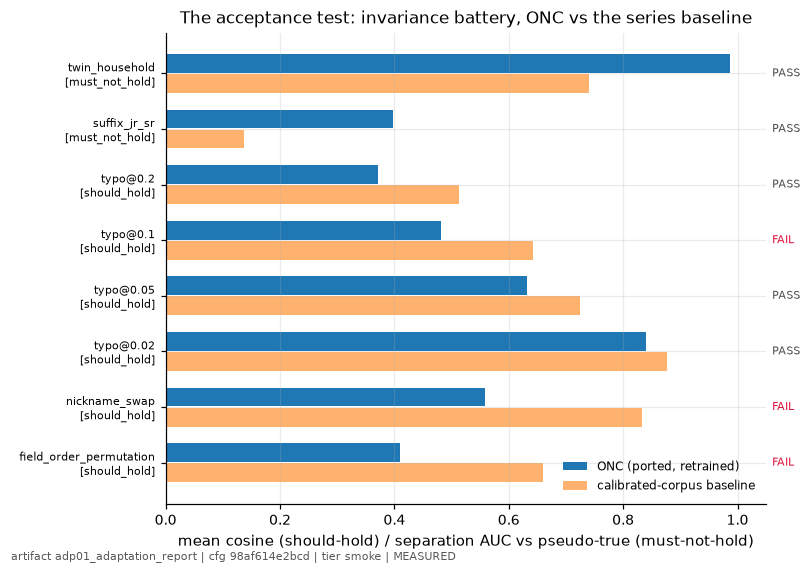

In [17]:
def draw_battery(ax, df, meta):
    d = df[df["row_type"] == "battery"].copy()
    d = d[d["n"].astype(float) > 0]
    d["_ord"] = (d["kind"] == "must_not_hold").astype(int)
    d = d.sort_values(["_ord", "slice"]).reset_index(drop=True)
    y = np.arange(len(d))
    onc_v = np.where(d["kind"] == "should_hold", d["mean_cos"], d["auc_vs_true"])
    base_v = np.where(d["kind"] == "should_hold", d["base_mean_cos"], d["base_auc"])
    ax.barh(y + 0.18, onc_v, height=0.34, label="ONC (ported, retrained)")
    ax.barh(y - 0.18, base_v, height=0.34, label="calibrated-corpus baseline", alpha=0.6)
    for i, r in d.iterrows():
        ok = r["passes"]
        if not pd.isna(ok):
            ax.annotate("PASS" if ok else "FAIL", (1.01, i), xycoords=("axes fraction", "data"),
                        fontsize=7.5, color="0.3" if ok else "crimson", va="center",
                        annotation_clip=False)
    ax.set_yticks(y, [f"{r['slice']}\n[{r['kind']}]" for _, r in d.iterrows()], fontsize=7.5)
    ax.set_xlabel("mean cosine (should-hold) / separation AUC vs pseudo-true "
                  "(must-not-hold)")
    ax.set_xlim(0, 1.05)
    ax.legend(loc="lower right", fontsize=8)


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="adp01_adaptation_report", draw=draw_battery,
    title="The acceptance test: invariance battery, ONC vs the series baseline",
    figsize=(7.4, 5.2),
)

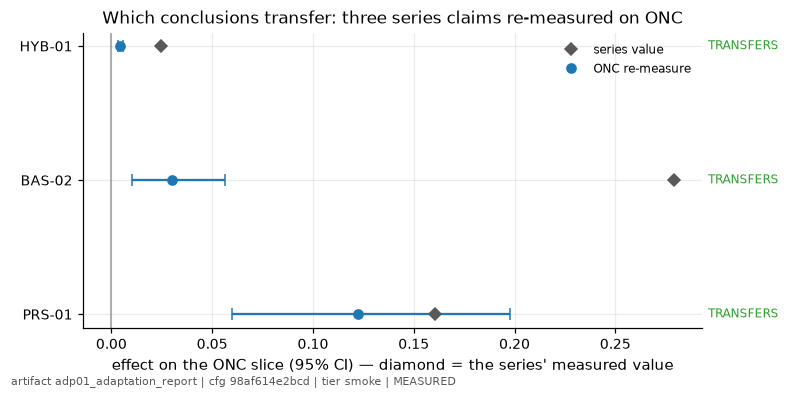

In [18]:
def draw_transfer(ax, df, meta):
    d = df[df["row_type"] == "transfer"].reset_index(drop=True)
    y = np.arange(len(d))
    for i, r in d.iterrows():
        lo, hi, x = float(r["onc_lo"]), float(r["onc_hi"]), float(r["onc_delta"])
        ax.errorbar([x], [i], xerr=[[x - lo], [hi - x]], fmt="o", capsize=4, markersize=6,
                    color="tab:blue")
        ax.plot([float(r["series_delta"])], [i], marker="D", color="0.35", markersize=6,
                linestyle="none")
        ax.annotate(str(r["status"]), (1.01, i), xycoords=("axes fraction", "data"),
                    fontsize=8, va="center", annotation_clip=False,
                    color={"TRANSFERS": "tab:green", "FLIPS": "crimson",
                           "UNDERPOWERED": "0.4"}[str(r["status"])])
    ax.axvline(0.0, color="0.6", linewidth=1)
    ax.set_yticks(y, [str(c).split(":")[0] for c in d["claim"]])
    ax.set_xlabel("effect on the ONC slice (95% CI) — diamond = the series' measured value")
    ax.plot([], [], marker="D", color="0.35", linestyle="none", label="series value")
    ax.plot([], [], marker="o", color="tab:blue", linestyle="none", label="ONC re-measure")
    ax.legend(loc="best", fontsize=8)


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="adp01_adaptation_report", draw=draw_transfer,
    title="Which conclusions transfer: three series claims re-measured on ONC",
    figsize=(7.2, 3.6),
)

### Verdict — ADP-01, scored against its pre-registered rule

In [19]:
P1 = bool(LINES_TOTAL <= CONFIG_LINES_BAR and PACKAGE_EDITS == 0)
P3 = bool(not AUDIT_APPLICABLE)  # declared not-applicable + fallback stated in §3c
if not P1:
    adp01_outcome = "REFUTED"
elif P1 and P2_BATTERY and P3:
    adp01_outcome = "CONFIRMED"
else:
    adp01_outcome = "UNEXPLAINED"
print(f"P1 (config-only port): {LINES_TOTAL} lines <= {CONFIG_LINES_BAR} and "
      f"{PACKAGE_EDITS} package edits -> {P1}")
print(f"P2 (battery acceptance): {P2_BATTERY} "
      f"({int(_scoreable['passes'].sum())}/{len(_scoreable)} scoreable slices)")
print(f"P3 (applicability honesty): audit declared not-applicable = {P3}")
print(f"-> outcome: {adp01_outcome}")

_ = verdict_box(
    "ADP-01",
    outcome=adp01_outcome,
    evidence=(
        f"adp01_adaptation_report (tier {TIER}). P1: {SCHEMA_LINES}-line schema YAML + "
        f"{len(DOTLIST_OVERRIDES)} dotlist overrides = {LINES_TOTAL} lines (bar "
        f"{CONFIG_LINES_BAR}), package edits {PACKAGE_EDITS} (git-verified) -> {P1}. "
        f"P2: {int(_scoreable['passes'].sum())}/{len(_scoreable)} scoreable battery "
        f"slices within the pre-registered bars (mean_cos −{BATTERY_TOL_COS} should-hold, "
        f"AUC −{BATTERY_TOL_AUC} must-not-hold) vs the calibrated-corpus baseline"
        + (f"; failing slices {_failing} — the invariance cost of the starved "
           f"{_n_pool_pairs}-pair conservative pseudo-label pool (§3f), which is what "
           "'not yet acceptance-ready at this budget' means concretely" if _failing
           else "")
        + f"; empty slices {_empty} reported unscored (Excel-serial dob defeats the "
        f"birth-year probe and format_drift alike) -> {P2_BATTERY}. P3: NB04 audit NOT "
        f"APPLICABLE on ONC (EnterpriseID "
        f"unique per row — measured; single release), generic-noise fallback stated with "
        f"its NSE-02 caveat -> {P3}. Transfer table: "
        + "; ".join(f"{str(r['claim']).split(':')[0]} {r['status']}"
                    for _, r in transfer_df.iterrows())
        + ". All ONC quality numbers are PSEUDO-truth (FS-agreement teacher), within-lab "
        "only and biased toward string-based systems. SINGLE-SEED DEMONSTRATION: one "
        "seed, one segment; MET-04 bars detect_bar_single_seed "
        f"{BAR_SINGLE:.4f} / detect_bar_residual_inclusive {BAR_FULL:.4f} (B3F1) — "
        "margins inside them are noise, and the mid-tier rerun is the adjudication."
    ),
    registry=registry,
)
tick("§5 register + verdict ADP-01", t_sec)

P1 (config-only port): 20 lines <= 30 and 0 package edits -> True
P2 (battery acceptance): False (5/8 scoreable slices)
P3 (applicability honesty): audit declared not-applicable = True
-> outcome: UNEXPLAINED


> ### VERDICT: UNEXPLAINED — card `ADP-01`
>
> **Conjecture** Pointing this lab at a new corpus and schema (ONC patient matching: full DOB as an Excel-style serial, an SSN-format field, street addresses, no released answer key) is a configuration exercise, not an engineering project: one DeclaredSchema YAML plus dotlist overrides port the whole pipeline with zero er_lab package edits, the serialization and raw-cosine scoring conventions transfer unchanged, and the invariance battery serves as the acceptance test against the calibrated-corpus baseline.
>
> **Prediction** P1: total configuration changed <= 30 lines (schema YAML non-comment lines + dotlist overrides), with ZERO package edits (git-verified). P2 (acceptance battery): on every probe slice populated in BOTH batteries, the ONC encoder's should-hold mean cosine is no more than 0.15 below the calibrated-corpus trained baseline, and each must-not-hold separation AUC is no more than 0.10 below it (empty slices are reported, not scored — e.g. Excel-serial DOBs defeat the birth-year probe by construction). P3 (applicability honesty): the NB04 noise audit is declared NOT APPLICABLE (single release, no stable person key) and the generic-noise fallback carries its stated caveat. Decision rule, pre-registered: REFUTED iff P1 fails; CONFIRMED iff P1 AND P2 AND P3; UNEXPLAINED otherwise (a battery miss means the port is not yet acceptance-ready at this budget — that reading is the point of the test). Pseudo-truth is FS-agreement-born, so every FS-flattering comparison is biased in FS's favor and is read as within-lab only; one seed, one segment: a demonstration against the MET-04 bars, never an adjudication.
>
> **Evidence** adp01_adaptation_report (tier smoke). P1: 18-line schema YAML + 2 dotlist overrides = 20 lines (bar 30), package edits 0 (git-verified) -> True. P2: 5/8 scoreable battery slices within the pre-registered bars (mean_cos −0.15 should-hold, AUC −0.1 must-not-hold) vs the calibrated-corpus baseline; failing slices ['field_order_permutation', 'nickname_swap', 'typo@0.1'] — the invariance cost of the starved 182-pair conservative pseudo-label pool (§3f), which is what 'not yet acceptance-ready at this budget' means concretely; empty slices ['different_birth_year', 'format_drift'] reported unscored (Excel-serial dob defeats the birth-year probe and format_drift alike) -> False. P3: NB04 audit NOT APPLICABLE on ONC (EnterpriseID unique per row — measured; single release), generic-noise fallback stated with its NSE-02 caveat -> True. Transfer table: PRS-01 TRANSFERS; BAS-02 TRANSFERS; HYB-01 TRANSFERS. All ONC quality numbers are PSEUDO-truth (FS-agreement teacher), within-lab only and biased toward string-based systems. SINGLE-SEED DEMONSTRATION: one seed, one segment; MET-04 bars detect_bar_single_seed 0.0862 / detect_bar_residual_inclusive 0.0865 (B3F1) — margins inside them are noise, and the mid-tier rerun is the adjudication.


[section timing] §5 register + verdict ADP-01: 1s


## 6. ADP-02 — dedup becomes linkage, live on real NC

### 6a. Two sources from one aligned substrate

The county-68 aligned pairs (`corpus_registry.nc_snapshots.aligned_path`; same-NCID
across the 2024 and 2026 snapshots) become a **two-source linkage arena**: the a-side
records are source `nc2024`, the b-side records source `nc2026`, and same-NCID is the
linkage truth. A tier-scaled NCID sample keeps ~70% of persons in BOTH sources and
splits the rest into one-source-only distractors — linkage with unlinked mass, not a
toy bijection. NCID-disjoint train/eval halves; NCID itself carries the NB01-measured
3.2–3.7% duplicate share (dup-NCID rows were dropped at alignment — the substrate's
stated truth cleaning). Real person fields: masked displays, aggregates-only artifacts.

In [20]:
t_sec = time.time()
NC_FIELDS = ["given_name", "family_name", "age", "city", "zip", "sex"]
NC_TEXT_ROLES = list(NC_FIELDS)
_al_cols = (["ncid", "record_id_a", "record_id_b", "snapshot_date_a", "snapshot_date_b"]
            + [f"{f}_{s}" for f in NC_FIELDS for s in ("a", "b")])
aligned = pd.read_parquet(REPO_ROOT / creg["nc_snapshots"]["aligned_path"],
                          columns=_al_cols)
assert aligned["ncid"].is_unique, "aligned substrate must be one row per NCID"
_rng_nc = np.random.default_rng(PRIMARY_SEED + 301)
_n_ent = min(SIZES["nc_ncids"] or len(aligned), len(aligned))
sub = aligned.iloc[np.sort(_rng_nc.choice(len(aligned), size=_n_ent, replace=False))]
sub = sub.reset_index(drop=True)
_u = _rng_nc.random(len(sub))
role = np.where(_u < NC_OVERLAP, "both",
                np.where(_u < NC_OVERLAP + (1 - NC_OVERLAP) / 2, "a_only", "b_only"))
_tr_mask = _rng_nc.random(len(sub)) < 0.5
print(f"sampled {_n_ent:,} of {len(aligned):,} aligned county-"
      f"{creg['nc_snapshots']['counties']} NCIDs "
      f"(subsampling stated); roles: {pd.Series(role).value_counts().to_dict()}; "
      f"NCID-disjoint halves: {int(_tr_mask.sum()):,} train / "
      f"{int((~_tr_mask).sum()):,} eval NCIDs, 0 straddling by construction")


def nc_side_frame(rows: pd.DataFrame, side: str, tag: str) -> pd.DataFrame:
    """One snapshot side as a canonical-role frame (verbatim values; derived birth_year).

    birth_year := snapshot_year - age is DERIVED, for blocking passes and the override
    key only (NB14's dob-absent fallback; ±1 birthday-boundary noise stated) — it is NOT
    serialized: the encoder sees the verbatim fields, drift and all.
    """
    out = pd.DataFrame(index=pd.RangeIndex(len(rows)))
    for f in NC_FIELDS:
        out[f] = rows[f"{f}_{side}"].astype("string").reset_index(drop=True)
    snap_year = pd.to_numeric(
        rows[f"snapshot_date_{side}"].astype("string").str[:4].reset_index(drop=True),
        errors="coerce")
    age = pd.to_numeric(out["age"], errors="coerce")
    out["birth_year"] = (snap_year - age).astype("Int64").astype("string")
    out["snapshot_year"] = snap_year.astype("Int64").astype("string")
    out["record_id"] = (tag + ":"
                        + rows[f"record_id_{side}"].astype("string").reset_index(drop=True))
    out["entity_id"] = rows["ncid"].astype("string").reset_index(drop=True)
    out["source"] = tag
    return out


def nc_arena(mask: np.ndarray) -> pd.DataFrame:
    rows_a = sub[mask & (role != "b_only")]
    rows_b = sub[mask & (role != "a_only")]
    return pd.concat([nc_side_frame(rows_a, "a", "nc2024"),
                      nc_side_frame(rows_b, "b", "nc2026")], ignore_index=True)


nc_train = nc_arena(_tr_mask)
nc_eval = nc_arena(~_tr_mask)
_ev_link = int((role[~_tr_mask] == "both").sum())
print(f"arenas: train {len(nc_train):,} records / eval {len(nc_eval):,} records "
      f"({_ev_link:,} eval NCIDs truly linked across sources; the rest are one-source "
      "distractors)")
_agree = (sub["age_a"].astype(float) - sub["age_b"].astype(float)).value_counts().head(3)
print(f"the drift that defines the task: age_a - age_b distribution (top) "
      f"{_agree.to_dict()} — ages moved 2 years between snapshots, so any exact-age "
      "matchkey pass yields ZERO cross-source pairs; the schema-aware fix below blocks "
      "on derived birth_year instead (config-level, not a package edit)")
_mrow = sub[role == "both"].iloc[0]
_mask_pair = {f"{f}({s})": mask_value(f, _mrow[f"{f}_{s}"])
              for f in ("given_name", "family_name", "age", "city", "zip")
              for s in ("a", "b")}
print("masked linked-pair example (initials+length only — real NC person fields never "
      "display raw):")
display(pd.Series(_mask_pair).to_frame("masked value"))
tick("§6a linkage sources", t_sec)

sampled 5,000 of 391,257 aligned county-[68] NCIDs (subsampling stated); roles: {'both': 3486, 'b_only': 773, 'a_only': 741}; NCID-disjoint halves: 2,499 train / 2,501 eval NCIDs, 0 straddling by construction
arenas: train 4,268 records / eval 4,218 records (1,717 eval NCIDs truly linked across sources; the rest are one-source distractors)
the drift that defines the task: age_a - age_b distribution (top) {-2.0: 5000} — ages moved 2 years between snapshots, so any exact-age matchkey pass yields ZERO cross-source pairs; the schema-aware fix below blocks on derived birth_year instead (config-level, not a package edit)
masked linked-pair example (initials+length only — real NC person fields never display raw):


,masked value
given_name(a),C.(8)
given_name(b),C.(8)
family_name(a),J.(7)
family_name(b),J.(7)
age(a),53
age(b),55
city(a),MEBANE
city(b),MEBANE
zip(a),27302
zip(b),27302


[section timing] §6a linkage sources: 1s


### 6b. Retrain on the train half — the linkage signal IS the drift

Same NB12 recipe, third corpus of the notebook: entities are NCIDs, positives are
cross-snapshot record pairs of the same person — so every positive the loop draws
carries two years of real drift (age +2, moves, renames). NCID labels carry the
NB01-measured duplicate share as truth error; the entity-disjoint rail (by NCID)
is asserted above.

In [21]:
t_sec = time.time()
NC_KEEP = ["record_id", "entity_id"] + NC_TEXT_ROLES
_loop_roles_nc = [c for c in NC_KEEP if c in ROLES and c not in NON_TEXT_ROLES]
assert _loop_roles_nc == NC_TEXT_ROLES, "loop role rule diverges from NC_TEXT_ROLES"
set_all_seeds(PRIMARY_SEED)
nc_encoder = build_encoder(cfg)
_t0 = time.time()
nc_encoder, nc_hist = train_encoder(
    nc_encoder, nc_train[NC_KEEP], cfg, loss_name="infonce", miner_name="inbatch",
    augment_kind="none", steps=STEPS, seed=PRIMARY_SEED,
)
NC_TRAIN_SECS = time.time() - _t0
assert len(nc_hist) == STEPS, "budget violation on the NC retrain"
_t0 = time.time()
NC_EV_TEXTS = serialize_frame(nc_eval, text_roles=NC_TEXT_ROLES, scheme=SER_SCHEME,
                              missing=SER_MISSING).tolist()
NC_TR_TEXTS = serialize_frame(nc_train, text_roles=NC_TEXT_ROLES, scheme=SER_SCHEME,
                              missing=SER_MISSING).tolist()
NC_EV_EMB = nc_encoder.encode(NC_EV_TEXTS, batch_size=ENC_BATCH)
NC_TR_EMB = nc_encoder.encode(NC_TR_TEXTS, batch_size=ENC_BATCH)
NC_ENC_SECS = time.time() - _t0
NC_ENC_RATE = (len(NC_EV_TEXTS) + len(NC_TR_TEXTS)) / NC_ENC_SECS
print(f"retrained on NC linkage positives: {STEPS} steps x batch {BATCH} (asserted) in "
      f"{NC_TRAIN_SECS:.0f}s; text roles {NC_TEXT_ROLES} (verbatim, age drift included; "
      "dob does not exist in this schema — MET-06's identifiability hit, lived again); "
      f"encoded {len(NC_EV_TEXTS) + len(NC_TR_TEXTS):,} records in {NC_ENC_SECS:.0f}s "
      f"({NC_ENC_RATE:,.0f} rec/s)")
tick("§6b NC retrain + encode", t_sec)

retrained on NC linkage positives: 250 steps x batch 64 (asserted) in 34s; text roles ['given_name', 'family_name', 'age', 'city', 'zip', 'sex'] (verbatim, age drift included; dob does not exist in this schema — MET-06's identifiability hit, lived again); encoded 8,486 records in 6s (1,382 rec/s)
[section timing] §6b NC retrain + encode: 40s


### 6c. The linkage conversion: one pair filter

Candidate generation runs exactly as in dedup (matchkeys with the birth-year pass +
dense ANN at the matched k), then ONE line converts the mode: **keep only cross-source
pairs**. The within-source pairs dropped by that filter are counted — they are dedup's
problem, deliberately out of scope in linkage mode — and candidate recall against the
linked eval NCIDs is measured with the honest denominator.

In [22]:
t_sec = time.time()
NC_PASSES = [["soundex(family_name)", "birth_year"], ["zip", "initial(given_name)"]]
mk_nc = matchkeys.candidates(nc_eval, passes=NC_PASSES)
ann_nc = ann.candidates(nc_eval, NC_EV_EMB, k=K_TRANSFER, index="flat")
nc_up = pd.concat([mk_nc, ann_nc], ignore_index=True)
nc_up["a"], nc_up["b"] = nc_up["a"].astype(str), nc_up["b"].astype(str)
nc_up = nc_up.drop_duplicates(subset=["a", "b"]).reset_index(drop=True)
_src = nc_eval.set_index(nc_eval["record_id"].astype(str))["source"]
_cross = (_src.loc[nc_up["a"]].to_numpy() != _src.loc[nc_up["b"]].to_numpy())
N_WITHIN_DROPPED = int((~_cross).sum())
nc_pairs = nc_up[_cross].reset_index(drop=True)
NC_TRUTH = nc_eval.set_index(nc_eval["record_id"].astype(str))["entity_id"]
NC_RECORDS = pd.Index(NC_TRUTH.index)
NC_TRUE = (NC_TRUTH.loc[nc_pairs["a"]].to_numpy() == NC_TRUTH.loc[nc_pairs["b"]].to_numpy())
_linked_found = pd.Series(
    NC_TRUTH.loc[nc_pairs["a"][NC_TRUE]].to_numpy()).nunique()
print(f"candidates: {len(mk_nc):,} matchkey (passes {NC_PASSES}) + {len(ann_nc):,} "
      f"ann_flat k={K_TRANSFER} -> {len(nc_up):,} unique; THE CONVERSION: "
      f"{N_WITHIN_DROPPED:,} within-source pairs dropped, {len(nc_pairs):,} cross-source "
      "pairs kept (one boolean filter — the entire dedup->linkage change)")
print(f"candidate recall: {_linked_found:,} of {_ev_link:,} truly-linked eval NCIDs "
      f"({_linked_found / _ev_link:.1%}) have their cross-source pair in the graph; "
      f"edge positive rate {float(NC_TRUE.mean()):.4f}")
tick("§6c linkage candidates", t_sec)

candidates: 119,837 matchkey (passes [['soundex(family_name)', 'birth_year'], ['zip', 'initial(given_name)']]) + 29,310 ann_flat k=10 -> 145,694 unique; THE CONVERSION: 71,972 within-source pairs dropped, 73,722 cross-source pairs kept (one boolean filter — the entire dedup->linkage change)
candidate recall: 1,717 of 1,717 truly-linked eval NCIDs (100.0%) have their cross-source pair in the graph; edge positive rate 0.0233
[section timing] §6c linkage candidates: 0s


### 6d. Three systems, two representations, one protocol

AUC on the **raw cosine** (the binding convention: the isotonic map is only weakly
monotone; its tie collapse measurably shifts AUC — measured in NB14 at 0.019); the
override enters **rank-natively** (fires above the cosine range). Operating points keep
**calibrated probabilities**: isotonic refit in-domain on train-half cross-source
candidates (real NCID labels here, unlike ONC). Entity-level linkage metrics at fixed
precision with entity-unit BCa CIs; paired deltas on shared resamples.

In [23]:
t_sec = time.time()
NC_EV_POS = pd.Series(np.arange(len(nc_eval)), index=nc_eval["record_id"].astype(str))
NC_EV_RECS = nc_eval.set_index(nc_eval["record_id"].astype(str))
A_NC = NC_EV_RECS.loc[nc_pairs["a"]].reset_index(drop=True)
B_NC = NC_EV_RECS.loc[nc_pairs["b"]].reset_index(drop=True)
NC_COS = np.einsum("ij,ij->i", NC_EV_EMB[NC_EV_POS.loc[nc_pairs["a"]].to_numpy()],
                   NC_EV_EMB[NC_EV_POS.loc[nc_pairs["b"]].to_numpy()]).astype(float)
NC_JW, _ = fs_agreement(A_NC, B_NC, fuzzy=("given_name", "family_name", "city"),
                        exact=("zip",), min_fields=3)


def nc_override(recs_a: pd.DataFrame, recs_b: pd.DataFrame) -> np.ndarray:
    """Exact given+family + birth-year within ±1 (dob absent: NB14's fallback key)."""
    def eq(col: str) -> np.ndarray:
        va, vb = _norm_str(recs_a[col]).to_numpy(), _norm_str(recs_b[col]).to_numpy()
        ok = ~(pd.isna(va) | pd.isna(vb))
        out = np.zeros(len(recs_a), dtype=bool)
        out[ok] = va[ok] == vb[ok]
        return out

    ya = pd.to_numeric(recs_a["birth_year"], errors="coerce").to_numpy(dtype=float)
    yb = pd.to_numeric(recs_b["birth_year"], errors="coerce").to_numpy(dtype=float)
    gap = np.abs(ya - yb)
    return eq("given_name") & eq("family_name") & np.isfinite(gap) & (gap <= BY_TOL)


FIRES_NC = nc_override(A_NC, B_NC)
print(f"override fires on {int(FIRES_NC.sum()):,} of {len(nc_pairs):,} cross-source pairs "
      f"({float(FIRES_NC.mean()):.2%}); {float(NC_TRUE[FIRES_NC].mean()):.4f} of fires "
      "are true links (REAL NCID truth, not pseudo)")

# in-domain calibration refit on the TRAIN half (linkage-mode candidates, NCID labels)
mk_tr_nc = matchkeys.candidates(nc_train, passes=NC_PASSES)
_src_tr = nc_train.set_index(nc_train["record_id"].astype(str))["source"]
_ctr = (_src_tr.loc[mk_tr_nc["a"].astype(str)].to_numpy()
        != _src_tr.loc[mk_tr_nc["b"].astype(str)].to_numpy())
mk_tr_nc = mk_tr_nc[_ctr].reset_index(drop=True)
NC_TR_POS = pd.Series(np.arange(len(nc_train)), index=nc_train["record_id"].astype(str))
NC_TR_TRUTH = nc_train.set_index(nc_train["record_id"].astype(str))["entity_id"]
_trc = np.einsum("ij,ij->i",
                 NC_TR_EMB[NC_TR_POS.loc[mk_tr_nc["a"].astype(str)].to_numpy()],
                 NC_TR_EMB[NC_TR_POS.loc[mk_tr_nc["b"].astype(str)].to_numpy()])
_trl = (NC_TR_TRUTH.loc[mk_tr_nc["a"].astype(str)].to_numpy()
        == NC_TR_TRUTH.loc[mk_tr_nc["b"].astype(str)].to_numpy()).astype(float)
nc_iso = fit_calibrator(_trc.astype(float), _trl, method="isotonic")
NC_PROB = nc_iso.transform(NC_COS)
print(f"calibration refit: isotonic on {len(mk_tr_nc):,} train-half cross-source "
      f"candidates (positive rate {float(_trl.mean()):.4f}) — ops on these probabilities, "
      "AUC on the raw cosine (declared representation)")

NC_AUC_INPUTS = {
    "fs_standin": NC_JW,
    "embedding": NC_COS,  # RAW cosine — the declared AUC representation
    "emb+override": np.where(FIRES_NC, 2.0, NC_COS),  # rank-native: above the cosine range
}
nc_pts, nc_dds, _ = auc_table(NC_AUC_INPUTS, np.asarray(NC_TRUE, bool), cap=AUC_CAP,
                              n_boot=N_BOOT_AUC, seed=PRIMARY_SEED + 77)
nc_auc_rows = [
    {"row_type": "auc", "system": k, "auc": v["auc"], "auc_lo": v["lo"], "auc_hi": v["hi"],
     "n_pairs": v["n_pairs"], "pos_rate": v["pos_rate"], "level": "pair",
     "universe": "cross-source union graph", "basis": "MEASURED"}
    for k, v in nc_pts.items()]
nc_auc_delta_rows = [
    {"row_type": "auc_delta", "system": ka, "system_b": kb, "delta": v["delta"],
     "delta_lo": v["lo"], "delta_hi": v["hi"], "sign_stable": float(v["sign_stable"]),
     "level": "pair", "basis": "MEASURED"}
    for (ka, kb), v in nc_dds.items()]
print("pair-level linkage AUC (raw-cosine representation, shared pair resamples):")
for k, v in nc_pts.items():
    print(f"  {k:>12}: {v['auc']:.4f} [{v['lo']:.4f}, {v['hi']:.4f}]")

NC_SYSTEMS_PROB = {
    "fs_standin": NC_JW,
    "embedding": NC_PROB,
    "emb+override": np.where(FIRES_NC, 1.0, NC_PROB),
}
NC_PRED_CACHE: dict[tuple[str, float], pd.Series] = {}
_NC_SFRAMES = {name: pd.DataFrame({"a": nc_pairs["a"], "b": nc_pairs["b"],
                                   "score": s, "prob": s})
               for name, s in NC_SYSTEMS_PROB.items()}


def nc_pred_at(system: str, thr: float) -> pd.Series:
    key = (system, float(thr))
    if key not in NC_PRED_CACHE:
        NC_PRED_CACHE[key] = transitive_closure(_NC_SFRAMES[system], threshold=float(thr),
                                                records=NC_RECORDS)
    return NC_PRED_CACHE[key]


nc_op_rows: list[dict] = []
NC_PREDS: dict[str, pd.Series] = {}
for system in NC_SYSTEMS_PROB:
    for target in PREC_TARGETS:
        res = find_threshold_for_precision(
            _NC_SFRAMES[system][["a", "b", "score"]],
            lambda t, s=system: nc_pred_at(s, t), NC_TRUTH, target=target, grid=GRID)
        pred = nc_pred_at(system, res["threshold"])
        if target == PREC_PRIMARY:
            NC_PREDS[system] = pred
        ci = bootstrap_ci(pred, NC_TRUTH, "bcubed_f1", unit="entity", n_boot=N_BOOT,
                          seed=PRIMARY_SEED)
        nc_op_rows.append({
            "row_type": "op", "system": system, "protocol": f"precision@{target}",
            "threshold": float(res["threshold"]), "attained": float(res["attained"]),
            "fallback": res["fallback"] or "", "precision": res["attained_precision"],
            "recall": res["recall_at"], "f1": ci["point"], "f1_lo": ci["ci_low"],
            "f1_hi": ci["ci_high"], "basis": "MEASURED"})
        flag = "" if res["attained"] else (f"  <-- {target} UNATTAINABLE (max "
                                           f"{res['attained_precision']:.4f}); loud "
                                           "fallback, PLAN §5")
        print(f"[{system}] linkage precision@{target}: t={res['threshold']:.4f} "
              f"P={res['attained_precision']:.4f} R={res['recall_at']:.4f} "
              f"B3F1={ci['point']:.4f} [{ci['ci_low']:.4f},{ci['ci_high']:.4f}]{flag}")

d_ov_nc = paired_delta(NC_PREDS["emb+override"], NC_PREDS["embedding"], NC_TRUTH,
                       "bcubed_f1", unit="entity", n_boot=N_BOOT, seed=PRIMARY_SEED)
d_emb_fs = paired_delta(NC_PREDS["embedding"], NC_PREDS["fs_standin"], NC_TRUTH,
                        "bcubed_f1", unit="entity", n_boot=N_BOOT, seed=PRIMARY_SEED)
nc_delta_rows = [
    {"row_type": "op_delta", "system": "emb+override", "system_b": "embedding",
     "delta": d_ov_nc["delta"], "delta_lo": d_ov_nc["ci_low"],
     "delta_hi": d_ov_nc["ci_high"], "sign_stable": float(d_ov_nc["sign_stable"]),
     "protocol": f"precision@{PREC_PRIMARY}", "basis": "MEASURED"},
    {"row_type": "op_delta", "system": "embedding", "system_b": "fs_standin",
     "delta": d_emb_fs["delta"], "delta_lo": d_emb_fs["ci_low"],
     "delta_hi": d_emb_fs["ci_high"], "sign_stable": float(d_emb_fs["sign_stable"]),
     "protocol": f"precision@{PREC_PRIMARY}", "basis": "MEASURED"},
]
print(f"paired deltas at precision@{PREC_PRIMARY} (shared entity resamples): "
      f"override marginal {d_ov_nc['delta']:+.4f} [{d_ov_nc['ci_low']:+.4f},"
      f"{d_ov_nc['ci_high']:+.4f}] (sign_stable={d_ov_nc['sign_stable']}); "
      f"embedding − fs {d_emb_fs['delta']:+.4f} [{d_emb_fs['ci_low']:+.4f},"
      f"{d_emb_fs['ci_high']:+.4f}]")
tick("§6d linkage systems + ops", t_sec)

override fires on 1,706 of 73,722 cross-source pairs (2.31%); 0.9994 of fires are true links (REAL NCID truth, not pseudo)


calibration refit: isotonic on 64,325 train-half cross-source candidates (positive rate 0.0275) — ops on these probabilities, AUC on the raw cosine (declared representation)


pair-level linkage AUC (raw-cosine representation, shared pair resamples):
    fs_standin: 0.9939 [0.9902, 0.9967]
     embedding: 0.9981 [0.9965, 0.9993]
  emb+override: 0.9984 [0.9968, 0.9995]


[fs_standin] linkage precision@0.99: t=1.0000 P=1.0000 R=0.9938 B3F1=0.9969 [0.9956,0.9979]


[fs_standin] linkage precision@0.995: t=1.0000 P=1.0000 R=0.9938 B3F1=0.9969 [0.9956,0.9979]


[embedding] linkage precision@0.99: t=0.2500 P=0.9913 R=0.9945 B3F1=0.9929 [0.9910,0.9945]


[embedding] linkage precision@0.995: t=0.3301 P=0.9974 R=0.9941 B3F1=0.9957 [0.9941,0.9970]


[emb+override] linkage precision@0.99: t=0.3301 P=0.9974 R=0.9974 B3F1=0.9974 [0.9962,0.9984]


[emb+override] linkage precision@0.995: t=0.3301 P=0.9974 R=0.9974 B3F1=0.9974 [0.9962,0.9984]
paired deltas at precision@0.99 (shared entity resamples): override marginal +0.0045 [+0.0034,+0.0058] (sign_stable=True); embedding − fs -0.0040 [-0.0055,-0.0023]
[section timing] §6d linkage systems + ops: 16s


In [24]:
t_sec = time.time()
_conv_rows = [
    {"row_type": "conversion", "system": "", "detail": "within-source pairs dropped",
     "n": float(N_WITHIN_DROPPED), "basis": "MEASURED"},
    {"row_type": "conversion", "system": "", "detail": "cross-source pairs kept",
     "n": float(len(nc_pairs)), "basis": "MEASURED"},
    {"row_type": "conversion", "system": "",
     "detail": "linked eval NCIDs with their pair in the graph",
     "n": float(_linked_found), "basis": "MEASURED"},
    {"row_type": "conversion", "system": "", "detail": "package edits (git-verified)",
     "n": float(PACKAGE_EDITS), "basis": "MEASURED"},
]
adp02 = pd.concat(
    [pd.DataFrame(nc_auc_rows), pd.DataFrame(nc_auc_delta_rows),
     pd.DataFrame(nc_op_rows), pd.DataFrame(nc_delta_rows), pd.DataFrame(_conv_rows)],
    ignore_index=True)
for _col in adp02.columns:
    if adp02[_col].dtype == object:
        adp02[_col] = adp02[_col].astype("string")
registry.register(
    "adp02_linkage_results", adp02, cfg=cfg, tier=cfg.run.tier,
    meta={
        "card": "ADP-02",
        "design": f"two-source linkage on the county-{creg['nc_snapshots']['counties']} "
                  f"aligned substrate: nc2024 vs nc2026, {_n_ent} sampled NCIDs "
                  f"(overlap {NC_OVERLAP}), NCID-disjoint train/eval halves; candidate "
                  "pairs cross-source only (the conversion rows count the filter)",
        "row_types": {
            "auc": "pair-level linkage ROC AUC with pair-bootstrap 95% CI",
            "auc_delta": "shared-draw pairwise AUC deltas",
            "op": "entity-level linkage operating points (B-cubed, entity-BCa 95% CI) "
                  "at fixed precision",
            "op_delta": "paired entity-resample B3F1 deltas at the primary target",
            "conversion": "the dedup->linkage conversion ledger",
        },
        "scored_representation": {
            "auc_arms": "RAW cosine (embedding), rank-native override above the cosine "
                        "range (hybrid), JW-agreement score (fs) — tie-free per the "
                        "Wave-4 convention (isotonic tie collapse shifted AUC 0.019 in "
                        "NB14's measurement)",
            "operating_points": "in-domain isotonic probabilities (fit on train-half "
                                "cross-source candidates, NCID labels); override fires "
                                "to prob 1.0",
        },
        "truth": "same-NCID = linkage truth (REAL, with NB01's measured 3.2-3.7% "
                 "dup-NCID share as the stated truth-error floor; dup-NCID rows dropped "
                 "at alignment)",
        "encoder": {"recipe": "NB12 scratch-char", "model": dict(MODEL_SHAPE),
                    "steps": STEPS, "batch": BATCH, "train_secs": NC_TRAIN_SECS,
                    "text_roles": NC_TEXT_ROLES,
                    "note": "trained on cross-snapshot positives — every positive "
                            "carries 2 years of real drift"},
        "blocking": {"passes": NC_PASSES,
                     "note": "exact-age pass yields zero cross-source pairs (ages moved "
                             "+2); derived birth_year = snapshot_year - age keys the "
                             "pass — config-level schema adaptation, measured in §6a"},
        "governance": "real NC person fields: masked displays, AGGREGATES ONLY in this "
                      "artifact (DATA_GOVERNANCE.md)",
        "met04": {"detect_bar_single_seed": BAR_SINGLE,
                  "detect_bar_residual_inclusive": BAR_FULL},
        "single_seed_caveat": "one seed, one county, one snapshot pair — a "
                              "DEMONSTRATION; the cross-state arm is "
                              "RUN-IN-TARGET(node), user-side data-gated",
    },
)
print(f"registered adp02_linkage_results: {len(adp02)} rows "
      f"({dict(adp02['row_type'].value_counts())})")

registered adp02_linkage_results: 18 rows ({'op': 6, 'conversion': 4, 'auc': 3, 'auc_delta': 3, 'op_delta': 2})


[section timing] §6e register + figure: 0s


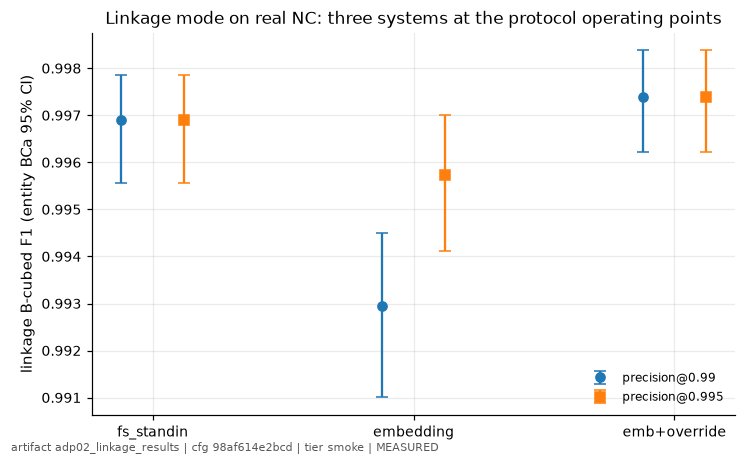

In [25]:
def draw_linkage(ax, df, meta):
    d = df[(df["row_type"] == "op")].copy()
    d["target"] = d["protocol"].str.extract(r"@([\d.]+)").astype(float)
    order = ["fs_standin", "embedding", "emb+override"]
    xs = {s: i for i, s in enumerate(order)}
    for target, g in d.groupby("target"):
        g = g.set_index("system").reindex(order).reset_index()
        x = g["system"].map(xs).to_numpy(dtype=float) + (0.12 if target > 0.99 else -0.12)
        yerr = np.vstack([np.clip(g["f1"] - g["f1_lo"], 0, None),
                          np.clip(g["f1_hi"] - g["f1"], 0, None)])
        fmt = "o" if target == 0.99 else "s"
        ax.errorbar(x, g["f1"], yerr=yerr, fmt=fmt, capsize=4, markersize=6,
                    label=f"precision@{target:g}"
                          + (" (fallback)" if (g["attained"] < 1).any() else ""))
    ax.set_xticks(range(len(order)), order)
    ax.set_ylabel("linkage B-cubed F1 (entity BCa 95% CI)")
    ax.legend(loc="lower right", fontsize=8)


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="adp02_linkage_results", draw=draw_linkage,
    title="Linkage mode on real NC: three systems at the protocol operating points",
    figsize=(6.8, 4.2),
)
tick("§6e register + figure", t_sec)

### 6f. The cross-STATE arm — priced from this run's coefficients

The ADP-02 target-tier arm links NC (no full DOB) against Ohio (full DOB, statewide key)
— the identifiability contrast MET-06 quantified, now in the linked setting. Ohio's
voter file is a **user-side download** (ohiosos.gov is blocked from build containers;
checksum-gated loader, aggregates only — DATA_GOVERNANCE.md), so at smoke this cell
prints the placard with estimates scaled from THIS run's measured coefficients; at
`tier=target` on the node the same cell runs the arm.

In [26]:
# [RUN-IN-TARGET node] NC<->OH cross-state linkage: the same §6 cells at tier=target — the
# full aligned NC substrate vs the Ohio statewide file through configs/schemas/ohio.yaml,
# candidates cross-state only, replicates per met04_power_table at that tier. No shared
# person key exists across states, so the arm is scored as an identifiability contrast
# (full-DOB vs no-DOB collision/ambiguity accounting per MET-06) plus the PLAN §10
# adjudicated pair sample (200-500 labeled via the widget), not as truth-scored accuracy.
if TIER == "target":
    try:
        ohio_df, ohio_schema = load_ohio(DATA_ROOT)
        print(f"loaded Ohio statewide file: {len(ohio_df):,} records — run the §6 cells "
              "against the full NC substrate with cross-STATE candidate filtering.")
    except FileNotFoundError as exc:
        print("[RUN-IN-TARGET node] Ohio data not present on this machine — the arm "
              "waits on the user-side download:\n" + str(exc))
else:
    N_NC_STATE, N_OH_STATE = 7.5e6, 8.0e6  # statewide planning sizes (±2x, PLAN §8)
    _enc_h = (N_NC_STATE + N_OH_STATE) / NC_ENC_RATE / 3600
    _pairs_25 = (N_NC_STATE + N_OH_STATE) * 25 / 2
    print(f"[RUN-IN-TARGET node] NC<->OH priced from THIS run's measured coefficients "
          f"(container, single seed, tier {TIER}):")
    print(f"  encode: measured {NC_ENC_RATE:,.0f} rec/s scratch-char on this container -> "
          f"~{_enc_h:,.0f} h for {N_NC_STATE + N_OH_STATE:,.0f} records here; PLAN §8 "
          f"books ~20k rec/s/GPU -> ~{(N_NC_STATE + N_OH_STATE) / 20_000 / 3600:.1f} "
          "GPU-h on the node (planning numbers, ±2x)")
    print(f"  candidates at k=25 cross-state: ~{_pairs_25:,.0f} pairs; memory for "
          f"{N_NC_STATE + N_OH_STATE:,.0f} x {MODEL_SHAPE['dim']}-d fp32 = "
          f"{(N_NC_STATE + N_OH_STATE) * MODEL_SHAPE['dim'] * 4 / 2**30:.0f} GB "
          "(target-tier 384-d: "
          f"{(N_NC_STATE + N_OH_STATE) * 384 * 4 / 2**30:.0f} GB) — inside the node's "
          "900 GB, sharded HNSW per BAS-02's measured build coefficients")
    print("  identifiability: OH carries full DOB (the SCL-04 collision-calibration "
          "source); NC does not — the contrast the arm exists to measure (MET-06). "
          "Truth: no cross-state key; scored as collision/ambiguity accounting + the "
          "adjudicated sample (PLAN §10.4). Ohio acquisition is user-side and "
          "checksum-gated; aggregates only (DATA_GOVERNANCE.md).")

[RUN-IN-TARGET node] NC<->OH priced from THIS run's measured coefficients (container, single seed, tier smoke):
  encode: measured 1,382 rec/s scratch-char on this container -> ~3 h for 15,500,000 records here; PLAN §8 books ~20k rec/s/GPU -> ~0.2 GPU-h on the node (planning numbers, ±2x)
  candidates at k=25 cross-state: ~193,750,000 pairs; memory for 15,500,000 x 128-d fp32 = 7 GB (target-tier 384-d: 22 GB) — inside the node's 900 GB, sharded HNSW per BAS-02's measured build coefficients
  identifiability: OH carries full DOB (the SCL-04 collision-calibration source); NC does not — the contrast the arm exists to measure (MET-06). Truth: no cross-state key; scored as collision/ambiguity accounting + the adjudicated sample (PLAN §10.4). Ohio acquisition is user-side and checksum-gated; aggregates only (DATA_GOVERNANCE.md).


### Verdict — ADP-02, scored against its pre-registered rule

In [27]:
ADP02_P1 = bool(PACKAGE_EDITS == 0)
ADP02_P2 = bool(d_ov_nc["delta"] >= 0
                and not (d_ov_nc["sign_stable"] and d_ov_nc["delta"] < 0))
ADP02_P3 = bool(nc_pts["emb+override"]["auc"] >= nc_pts["embedding"]["auc"])
if (not ADP02_P1) or (d_ov_nc["sign_stable"] and d_ov_nc["delta"] < 0):
    adp02_outcome = "REFUTED"
elif ADP02_P1 and ADP02_P2 and ADP02_P3:
    adp02_outcome = "CONFIRMED"
else:
    adp02_outcome = "UNEXPLAINED"
print(f"P1 (conversion, zero package edits): {ADP02_P1} "
      f"({N_WITHIN_DROPPED:,} within-source pairs dropped by the one-line filter)")
print(f"P2 (override marginal >= 0, not sign-stably negative): {ADP02_P2} "
      f"({d_ov_nc['delta']:+.4f} [{d_ov_nc['ci_low']:+.4f},{d_ov_nc['ci_high']:+.4f}])")
print(f"P3 (hybrid AUC >= embedding AUC): {ADP02_P3} "
      f"({nc_pts['emb+override']['auc']:.4f} vs {nc_pts['embedding']['auc']:.4f})")
print(f"-> outcome: {adp02_outcome}")

_ = verdict_box(
    "ADP-02",
    outcome=adp02_outcome,
    evidence=(
        f"adp02_linkage_results (tier {TIER}; {_n_ent:,} sampled county-68 NCIDs, "
        f"{len(nc_eval):,} eval records, {len(nc_pairs):,} cross-source candidate "
        f"pairs). P1: package edits {PACKAGE_EDITS} (git-verified); the conversion is "
        f"one cross-source filter ({N_WITHIN_DROPPED:,} within-source pairs dropped) "
        f"plus a schema-aware blocking pass (derived birth_year — the exact-age pass "
        f"yields zero cross-source pairs under the measured +2 age drift) -> "
        f"{ADP02_P1}. P2: override marginal at precision@{PREC_PRIMARY} = "
        f"{d_ov_nc['delta']:+.4f} [{d_ov_nc['ci_low']:+.4f},{d_ov_nc['ci_high']:+.4f}], "
        f"sign_stable={d_ov_nc['sign_stable']} -> {ADP02_P2}. P3: AUC "
        f"emb+override {nc_pts['emb+override']['auc']:.4f} vs embedding "
        f"{nc_pts['embedding']['auc']:.4f} (raw-cosine representation, rank-native "
        f"rules; declared in meta) -> {ADP02_P3}. Truth is same-NCID with NB01's "
        "measured 3.2-3.7% dup-NCID share as the error floor. SINGLE-SEED "
        "DEMONSTRATION: one seed, one county, one snapshot pair — MET-04 bars "
        f"detect_bar_single_seed {BAR_SINGLE:.4f} / detect_bar_residual_inclusive "
        f"{BAR_FULL:.4f} (B3F1); margins inside them are replicate noise. The "
        "cross-state NC<->OH arm (full-DOB vs no-DOB identifiability contrast) is "
        "RUN-IN-TARGET(node) and user-side data-gated."
    ),
    registry=registry,
)
tick("§6f verdict ADP-02", t_sec)

P1 (conversion, zero package edits): True (71,972 within-source pairs dropped by the one-line filter)
P2 (override marginal >= 0, not sign-stably negative): True (+0.0045 [+0.0034,+0.0058])
P3 (hybrid AUC >= embedding AUC): True (0.9984 vs 0.9981)
-> outcome: CONFIRMED


> ### VERDICT: CONFIRMED — card `ADP-02`
>
> **Conjecture** The dedup pipeline converts to two-source linkage by configuration and pair-universe restriction alone — candidate generation, scoring, calibration, clustering and metrics run unchanged on real NC data with snapshot A and snapshot B as the two sources and same-NCID as linkage truth — and HYB-01's finding that the exact-key override earns its place transfers to the linkage setting.
>
> **Prediction** P1 (conversion): zero er_lab package edits (git-verified); the linkage restriction is a stated in-notebook pair filter. P2 (HYB-01 transfer): the paired B-cubed F1 delta of embedding+override minus embedding at precision 0.99 is >= 0 and not sign-stably negative. P3: the override does not hurt the pair ranking either — hybrid AUC >= embedding AUC (point estimate, raw-cosine scale). Decision rule, pre-registered: REFUTED iff P1 fails or the override delta is sign-stably negative; CONFIRMED iff P1 AND P2 AND P3; UNEXPLAINED otherwise. Single seed, one county, one snapshot pair: a demonstration read against BOTH MET-04 bars (detect_bar_single_seed and detect_bar_residual_inclusive, quoted from met04_power_table meta); the NC-vs-OH cross-state arm is RUN-IN-TARGET(node) and user-side data-gated.
>
> **Evidence** adp02_linkage_results (tier smoke; 5,000 sampled county-68 NCIDs, 4,218 eval records, 73,722 cross-source candidate pairs). P1: package edits 0 (git-verified); the conversion is one cross-source filter (71,972 within-source pairs dropped) plus a schema-aware blocking pass (derived birth_year — the exact-age pass yields zero cross-source pairs under the measured +2 age drift) -> True. P2: override marginal at precision@0.99 = +0.0045 [+0.0034,+0.0058], sign_stable=True -> True. P3: AUC emb+override 0.9984 vs embedding 0.9981 (raw-cosine representation, rank-native rules; declared in meta) -> True. Truth is same-NCID with NB01's measured 3.2-3.7% dup-NCID share as the error floor. SINGLE-SEED DEMONSTRATION: one seed, one county, one snapshot pair — MET-04 bars detect_bar_single_seed 0.0862 / detect_bar_residual_inclusive 0.0865 (B3F1); margins inside them are replicate noise. The cross-state NC<->OH arm (full-DOB vs no-DOB identifiability contrast) is RUN-IN-TARGET(node) and user-side data-gated.


[section timing] §6f verdict ADP-02: 0s


## 7. The adaptation recipe — what you actually do, in order

The chapter's takeaway, with pointers to the notebook that demonstrated each step:

1. **Declare the schema** — one column→role YAML, nothing else (NB01; here §3a: 18
   lines).
2. **Point the config at it** — dotlist overrides, zero package edits (NB00's config
   contract; §3a, git-verified).
3. **Check noise-audit applicability** — stable key + ≥2 temporal versions (NB04's
   contract; §3c). *No* is a finding: fall back to generic noise and carry NSE-02's
   fidelity caveat (NB05).
4. **Inherit the serialization discipline** — fixed role order, `[MISSING]` token,
   `full_name` excluded (NB08's measured decision; §3d), and measure your byte window.
5. **Get labels honestly** — audit a truth key if one exists (NB03); otherwise build
   conservative pseudo-labels and carry NB11's circularity caveat on every number
   (§3e).
6. **Rebuild entity-disjoint splits** on whatever your entity is — pseudo-entities
   count (MET-07/NB05 discipline; §3e, straddle asserted).
7. **Retrain at a stated budget** — the NB12 scratch recipe transfers verbatim; assert
   the step count, state the positive-pool size (§3f, §6b).
8. **Run the invariance battery as the acceptance test** against your reference
   baseline — empty slices are schema information (NB08; §3g).
9. **Refit the calibrator in-domain**; score rankings on the raw cosine and operating
   points on calibrated probabilities — never mix the representations (NB13/NB14's
   convention; §3h, §6d).
10. **Re-measure, never assume, which conclusions transfer** — blocking gaps, parsing
    effects, rule value (§4); and convert dedup→linkage by restricting the pair
    universe cross-source (§6c) with schema-aware blocking keys (§6a).

**Artifacts registered** (exact names): `adp01_adaptation_report`,
`adp02_linkage_results` — plus the immutable cards `card_ADP-01`, `card_ADP-02`.

**Package gaps noted for the maintainers** (worked around in-notebook, zero package
edits): the ONC loader's contents-API discovery has no canned-name fallback when
`letters` is given (§3b); candidate generators have no linkage mode — the cross-source
filter lives in the notebook (§6c); the candidate-set pair-completeness bootstrap
remains notebook-local (NB12's gap, §4).

In [28]:
timing = pd.DataFrame(SECTION_TIMES, columns=["section", "secs"])
display(timing.assign(secs=timing["secs"].round(0)))
total = time.time() - NB_T0
print(f"notebook wall-clock: {total:.0f}s ({total / 60:.1f} min) — smoke budget <= ~30 min "
      "uncontended"
      + ("" if total <= 2100 else "  <-- OVER at this run (see section table; concurrent "
                                  "builds inflate wall-clock 2-4x)"))

,section,secs
0,§1 upstreams + bars,0.0
1,§3a schema + lines-of-config,0.0
2,§3b ONC load + key measurement,1.0
3,§3c audit applicability,0.0
4,§3d serialization,0.0
5,§3e pseudo-labels + split,2.0
6,§3f retrain + encode,47.0
7,§3g battery,22.0
8,§3h dedup eval,16.0
9,§4 transfer table,28.0


notebook wall-clock: 174s (2.9 min) — smoke budget <= ~30 min uncontended
